# 14 - Main use: OptimisationSimulation (`accim custom model`)

Objetivo: flujo de optimizacion simple con `OptimisationSimulation` para
`parameters_type="accim custom model"`, usando los mismos IDFs y EPWs
del notebook `01_parametric_accim_custom_model.ipynb`.

Se lanza una optimizacion corta NSGA-II por cada IDF.


In [1]:
from pathlib import Path

import pandas as pd
import accim
from besos import eppy_funcs as ef
from accim.parametric_and_optimisation.main import OptimisationSimulation

pd.set_option("display.max_columns", 160)


## Step 1 - Rutas y ajustes de optimizacion


In [2]:
PROJECT_ROOT = Path.cwd()

idf_list = [
    "OSM_TestResidentialUnit_v01_onlygeometry_SchNatVent_v2520_high_performance.idf",
    "OSM_TestResidentialUnit_v01_onlygeometry_SchNatVent_v2520_low_performance.idf",
]
epw_list = ["Seville.epw", "Sydney.epw"]
RESULTS_DIRNAME = "nb14_main_optim_custom_results_without_idf_loop"

EVALUATIONS = 6
POPULATION_SIZE = 3

print("IDF files found:", [(PROJECT_ROOT / idf).exists() for idf in idf_list])
print("EPW files found:", [(PROJECT_ROOT / epw).exists() for epw in epw_list])


IDF files found: [True, True]
EPW files found: [True, True]


## Step 2 - Ejecutar optimizacion multi-IDF (sin loop por IDF)


In [3]:
RUN_OPTIMIZATION = True
PARETO_SEPARATE_BY_EPW = True
PARETO_SEPARATE_BY_IDF = False

meter_names = ["Heating:Electricity", "Cooling:Electricity"]

def _load_and_prepare_building(idf_name: str):
    print("\nPreparing IDF:", idf_name)
    building = ef.get_building(idf_name)
    accim.utils.reduce_runtime(idf_object=building, timesteps=2)
    return building

buildings = [_load_and_prepare_building(idf_name) for idf_name in idf_list]

optim = OptimisationSimulation(
    buildings=buildings,
    parameters_type="accim custom model",
    epws=epw_list,
    output_freqs=["Hourly"],
)

try:
    available_outputs = optim.discover_available_outputs(
        reduce_sim_time=True,
        prefer="testsimeplus",
        idf_scope="first",
    )
    outputs_meta = available_outputs["meta"]
    print("Discovery source:", outputs_meta.get("source"))
    df_meters_sel = optim.select_outputs(
        meters=meter_names,
        match="case_insensitive",
        on_missing="raise",
        suggest=True,
        idf_scope="first",
    )["meters"]
except Exception as exc:
    print("Output discovery failed, using explicit meters.")
    print(f"Discovery error: {exc}")
    df_meters_sel = pd.DataFrame(
        {"key_name": meter_names, "frequency": ["Hourly"] * len(meter_names)}
    )

try:
    optim.apply_outputs_preflight(
        df_meters_sel=df_meters_sel,
        df_vars_sel=None,
        clean_mode="all",
        validate_before_apply=False,
        validate_after_apply=True,
        on_missing="raise",
        validation_idf_scope="first",
    )
except Exception as exc:
    print("Outputs preflight failed; applying selected meters directly.")
    print(f"Preflight error: {exc}")
optim.set_outputs_for_simulation(df_output_meter=df_meters_sel)

accis_parameters = {
    "CustAST_m": (0.20, 0.85),
    "CustAST_n": (9, 21),
    "CustAST_ASToffset": (1.0, 5.0),
    "CustAST_ASTall": (8, 14),
    "CustAST_ASTaul": (30, 37),
}
optim.set_parameters(accis_params_dict=accis_parameters)
optim.set_problem(minimize_outputs=[True, True])

estimated = optim.estimate_optimisation_sims(
    evaluations=EVALUATIONS,
    population_size=POPULATION_SIZE,
    epws=epw_list,
)
print("Estimated simulations:", estimated)

if RUN_OPTIMIZATION:
    run_result = optim.run_optimisation(
        epws=epw_list,
        out_dir=RESULTS_DIRNAME,
        evaluations=EVALUATIONS,
        population_size=POPULATION_SIZE,
        algorithm="NSGAII",
        processes=1,
        keep_df="all",
        keep_sim_files="non-dominated",
        keep_sim_files_batch_size=POPULATION_SIZE,
        pareto_separate_by_epw=PARETO_SEPARATE_BY_EPW,
        pareto_separate_by_idf=PARETO_SEPARATE_BY_IDF,
    )
    if isinstance(run_result, pd.DataFrame):
        outputs_optim = run_result.copy()
    else:
        outputs_optim = getattr(optim, "outputs_optimisation", pd.DataFrame()).copy()
else:
    print("Optimization skipped")
    outputs_optim = getattr(optim, "outputs_optimisation", pd.DataFrame()).copy()

print("Combined rows:", len(outputs_optim))
print(outputs_optim.head())



Preparing IDF: OSM_TestResidentialUnit_v01_onlygeometry_SchNatVent_v2520_high_performance.idf
Solar distribution has been set to MinimalShadowing.
Shading Calculation Update Frequency was previously set to 20 days, and it has been modified to 20 days.
Maximum Figures in Shadow Overlap Calculations was previously set to 15000 days, and it has been modified to 200 days.
Number of Timesteps per Hour was previously set to 6 days, and it has been modified to 2 days.

Preparing IDF: OSM_TestResidentialUnit_v01_onlygeometry_SchNatVent_v2520_low_performance.idf
Solar distribution has been set to MinimalShadowing.
Shading Calculation Update Frequency was previously set to 20 days, and it has been modified to 20 days.
Maximum Figures in Shadow Overlap Calculations was previously set to 15000 days, and it has been modified to 200 days.
Number of Timesteps per Hour was previously set to 6 days, and it has been modified to 2 days.

--------------------------------------------------------
Adaptive-

D:\Python\accim\accim\parametric_and_optimisation\main.py:2301: UserWarning: During class initialization, existing output objects are preserved by design. Use clear_outputs(...) later if you want to remove them explicitly.
  warnings.warn(


Cooling Fanger comfort setpoint: Always  0.1 Schedule has been added
Zone CO2 setpoint: Always 900ppm Schedule has been added
Min CO2 concentration: Always 600ppm Schedule has been added
Generic contaminant setpoint: Always 0.5ppm Schedule has been added
Air distribution effectiveness (always 1) Schedule has been added
VRF Heating Cooling (Northern Hemisphere) Schedule has been added
DefaultFanEffRatioCurve Curve:Cubic Object has been added
VRFTUCoolCapFT Curve:Cubic Object has been added
VRFTUHeatCapFT Curve:Cubic Object has been added
VRFCoolCapFTBoundary Curve:Cubic Object has been added
VRFCoolEIRFTBoundary Curve:Cubic Object has been added
CoolingEIRLowPLR Curve:Cubic Object has been added
VRFHeatCapFTBoundary Curve:Cubic Object has been added
VRFHeatEIRFTBoundary Curve:Cubic Object has been added
HeatingEIRLowPLR Curve:Cubic Object has been added
DefaultFanPowerRatioCurve Curve:Exponent Object has been added
DXHtgCoilDefrostEIRFT Curve:Biquadratic Object has been added
VRFCoolCap

C:\Users\sanga\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\besos\parameters.py:441: UserWarning: This parameter's descriptor is already named CustAST_m.The name used as an input (CustAST_m) will be discarded.
  warnings.warn(
C:\Users\sanga\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\besos\parameters.py:441: UserWarning: This parameter's descriptor is already named CustAST_n.The name used as an input (CustAST_n) will be discarded.
  warnings.warn(
C:\Users\sanga\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\besos\parameters.py:441: UserWarning: This parameter's descriptor is already named CustAST_ASToffset.The name used as an input (CustAST_ASToffset) will be discarded.
  warnings.warn(
C:\Users\sanga\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\besos\parameters.py:441: UserWarning: This parameter's descriptor is already named CustAST_ASTall.The name used as an input (CustAST_ASTall) will be discarded.
  warnings.warn(
C:\Users\sanga

Running EnergyPlus with stdout output suppressed...
Running EnergyPlus with stdout output suppressed...
Running EnergyPlus with stdout output suppressed...
Running EnergyPlus with stdout output suppressed...
Running EnergyPlus with stdout output suppressed...
Running EnergyPlus with stdout output suppressed...
Running EnergyPlus with stdout output suppressed...
Running EnergyPlus with stdout output suppressed...
Running EnergyPlus with stdout output suppressed...
Running EnergyPlus with stdout output suppressed...
Running EnergyPlus with stdout output suppressed...
Running EnergyPlus with stdout output suppressed...
Running EnergyPlus with stdout output suppressed...
Running EnergyPlus with stdout output suppressed...
Running EnergyPlus with stdout output suppressed...
Running EnergyPlus with stdout output suppressed...
Running EnergyPlus with stdout output suppressed...
Running EnergyPlus with stdout output suppressed...
Running EnergyPlus with stdout output suppressed...
Running Ener

## Step 3 - Normalizacion (AnalysisMixin) y visualizacion (PlottingMixin)


  [info] Building floor area [OSM_TestResidentialUnit_v01_onlygeometry_SchNatVent_v2520_high_performance]: 185.81 m²
  [info] Building floor area [OSM_TestResidentialUnit_v01_onlygeometry_SchNatVent_v2520_low_performance]: 185.81 m²
  [info] Normalized 2 energy columns in outputs_optimisation.


C:\Users\sanga\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


  Categorical boxplot saved: nb14_main_optim_custom_results_without_idf_loop/plots\plot_categorical_boxplots_optimisation_col_epw_hue_CustAST_m.png
  Parametric scatter plot saved: nb14_main_optim_custom_results_without_idf_loop/plots\plot_parametric_scatter_optimisation_CustAST_m_vs_Heating_Electricity_kWh_m2.png
  Parametric line plot saved: nb14_main_optim_custom_results_without_idf_loop/plots\plot_parametric_lines_optimisation_Heating_Electricity_kWh_m2_by_CustAST_n.png
  Parametric line plot saved: nb14_main_optim_custom_results_without_idf_loop/plots\plot_parametric_lines_optimisation_Cooling_Electricity_kWh_m2_by_CustAST_n.png
  Parametric heatmap saved: nb14_main_optim_custom_results_without_idf_loop/plots\plot_parametric_heatmap_optimisation_Heating_Electricity_kWh_m2_by_CustAST_m_CustAST_n.png
  Parametric 2D density plot saved: nb14_main_optim_custom_results_without_idf_loop/plots\plot_parametric_density2d_hexbin_optimisation_CustAST_ASToffset_vs_Heating_Electricity_kWh_m2.p

C:\Users\sanga\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#366cd9'` for the same effect.

  func(*plot_args, **plot_kwargs)


  Parametric violin plot saved: nb14_main_optim_custom_results_without_idf_loop/plots\plot_parametric_violin_optimisation_Heating_Electricity_kWh_m2_by_epw.png


C:\Users\sanga\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#366cd9'` for the same effect.

  func(*plot_args, **plot_kwargs)


  Parametric violin plot saved: nb14_main_optim_custom_results_without_idf_loop/plots\plot_parametric_violin_optimisation_Cooling_Electricity_kWh_m2_by_epw.png
  Parametric ECDF plot saved: nb14_main_optim_custom_results_without_idf_loop/plots\plot_parametric_ecdf_optimisation_Heating_Electricity_kWh_m2.png
  Parametric radar plot saved: nb14_main_optim_custom_results_without_idf_loop/plots\plot_parametric_radar_optimisation_group_epw.png
  Pareto front plot saved: nb14_main_optim_custom_results_without_idf_loop/plots\plot_pareto_front_Seville_c_CustAST_ASToffset_s_CustAST_m.png
  Pareto front plot saved: nb14_main_optim_custom_results_without_idf_loop/plots\plot_pareto_front_Sydney_c_CustAST_ASToffset_s_CustAST_m.png
  Parallel coordinates plot saved: nb14_main_optim_custom_results_without_idf_loop/plots\plot_parallel_coordinates_Seville.png
  Parallel coordinates plot saved: nb14_main_optim_custom_results_without_idf_loop/plots\plot_parallel_coordinates_Sydney.png
  Pairwise scatter 

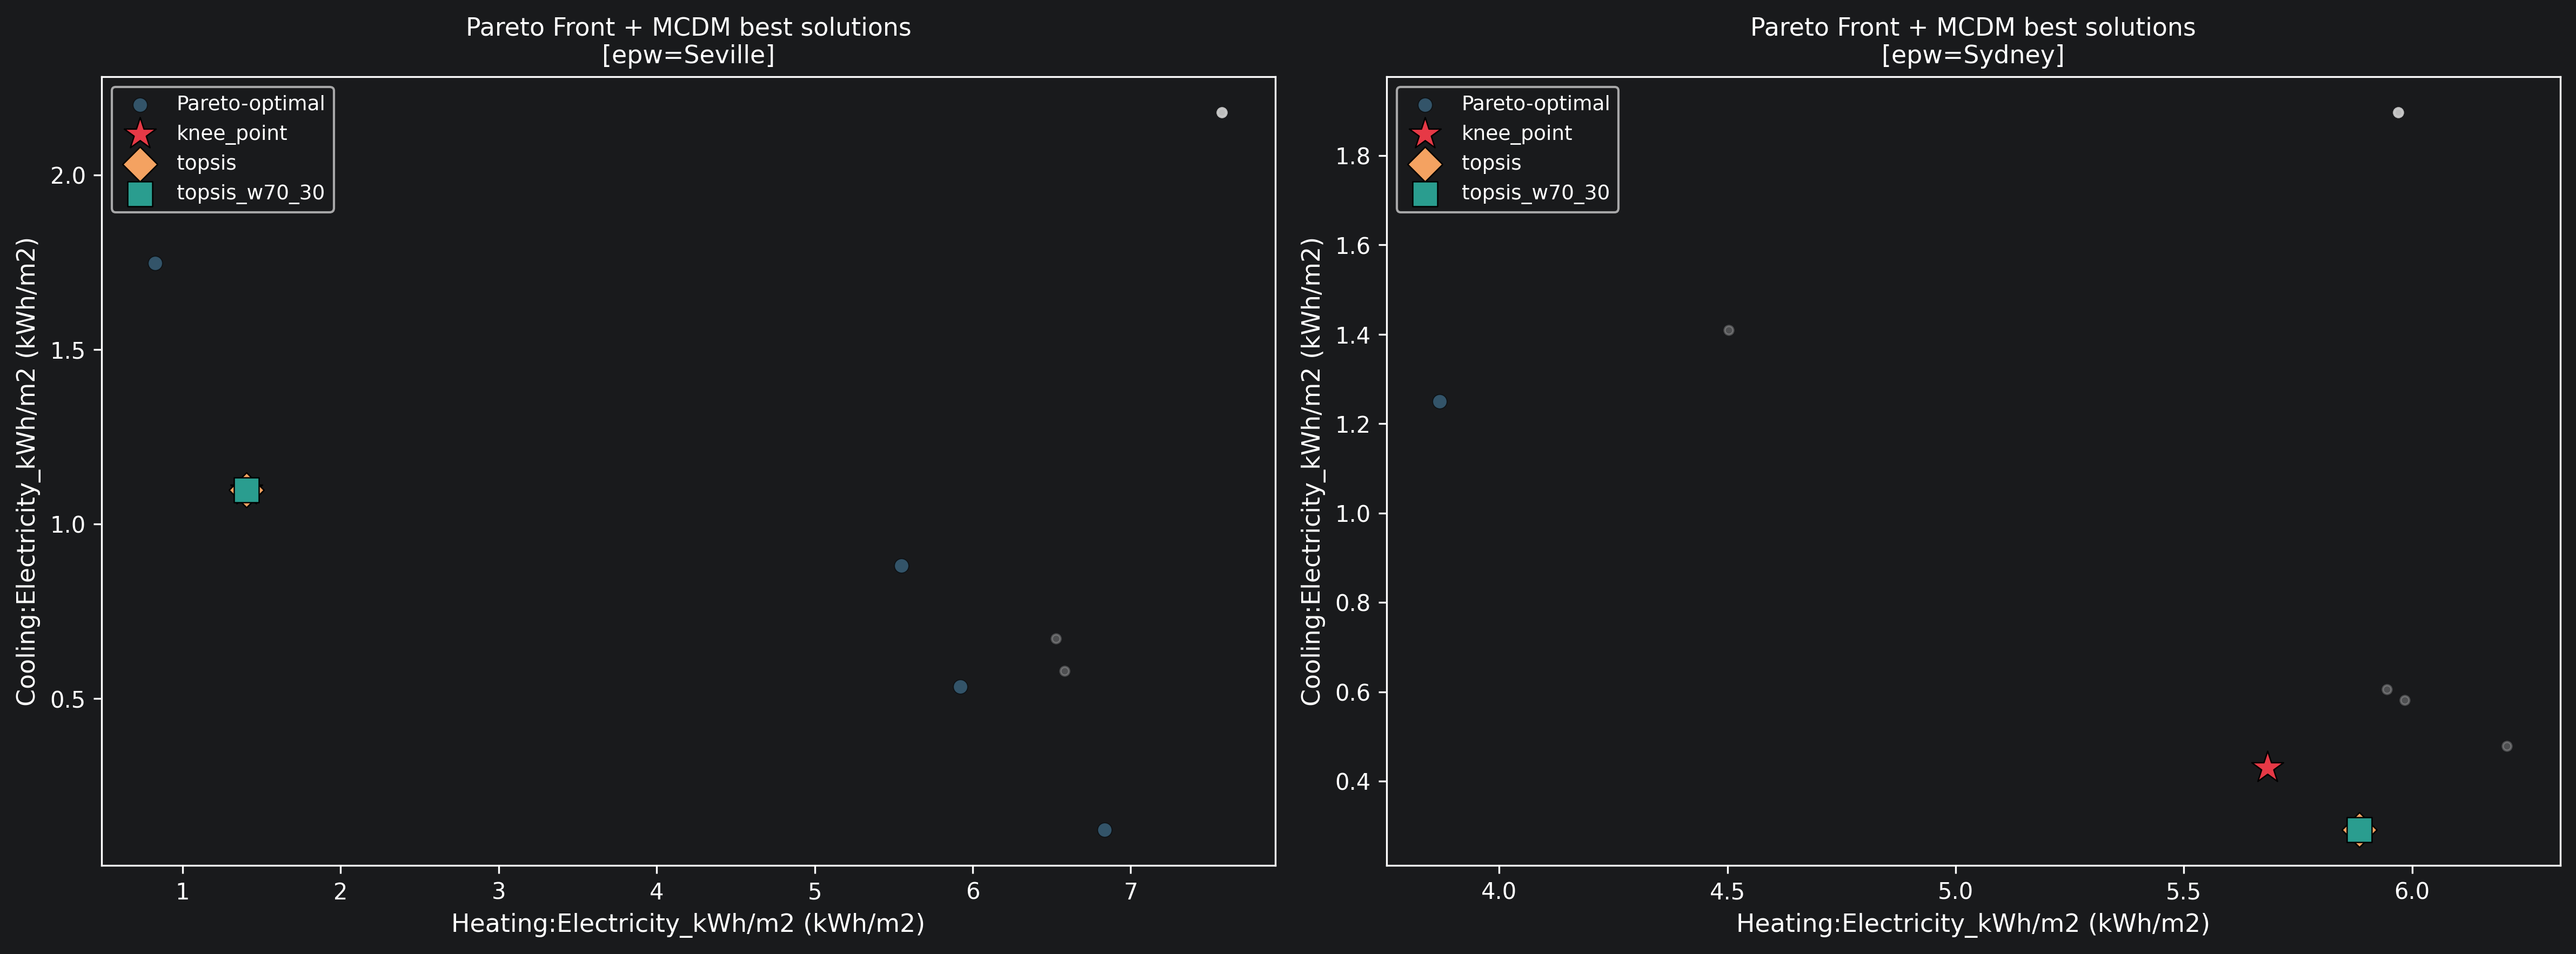

 - plot_pairwise_scatter_matrix_Sydney.png


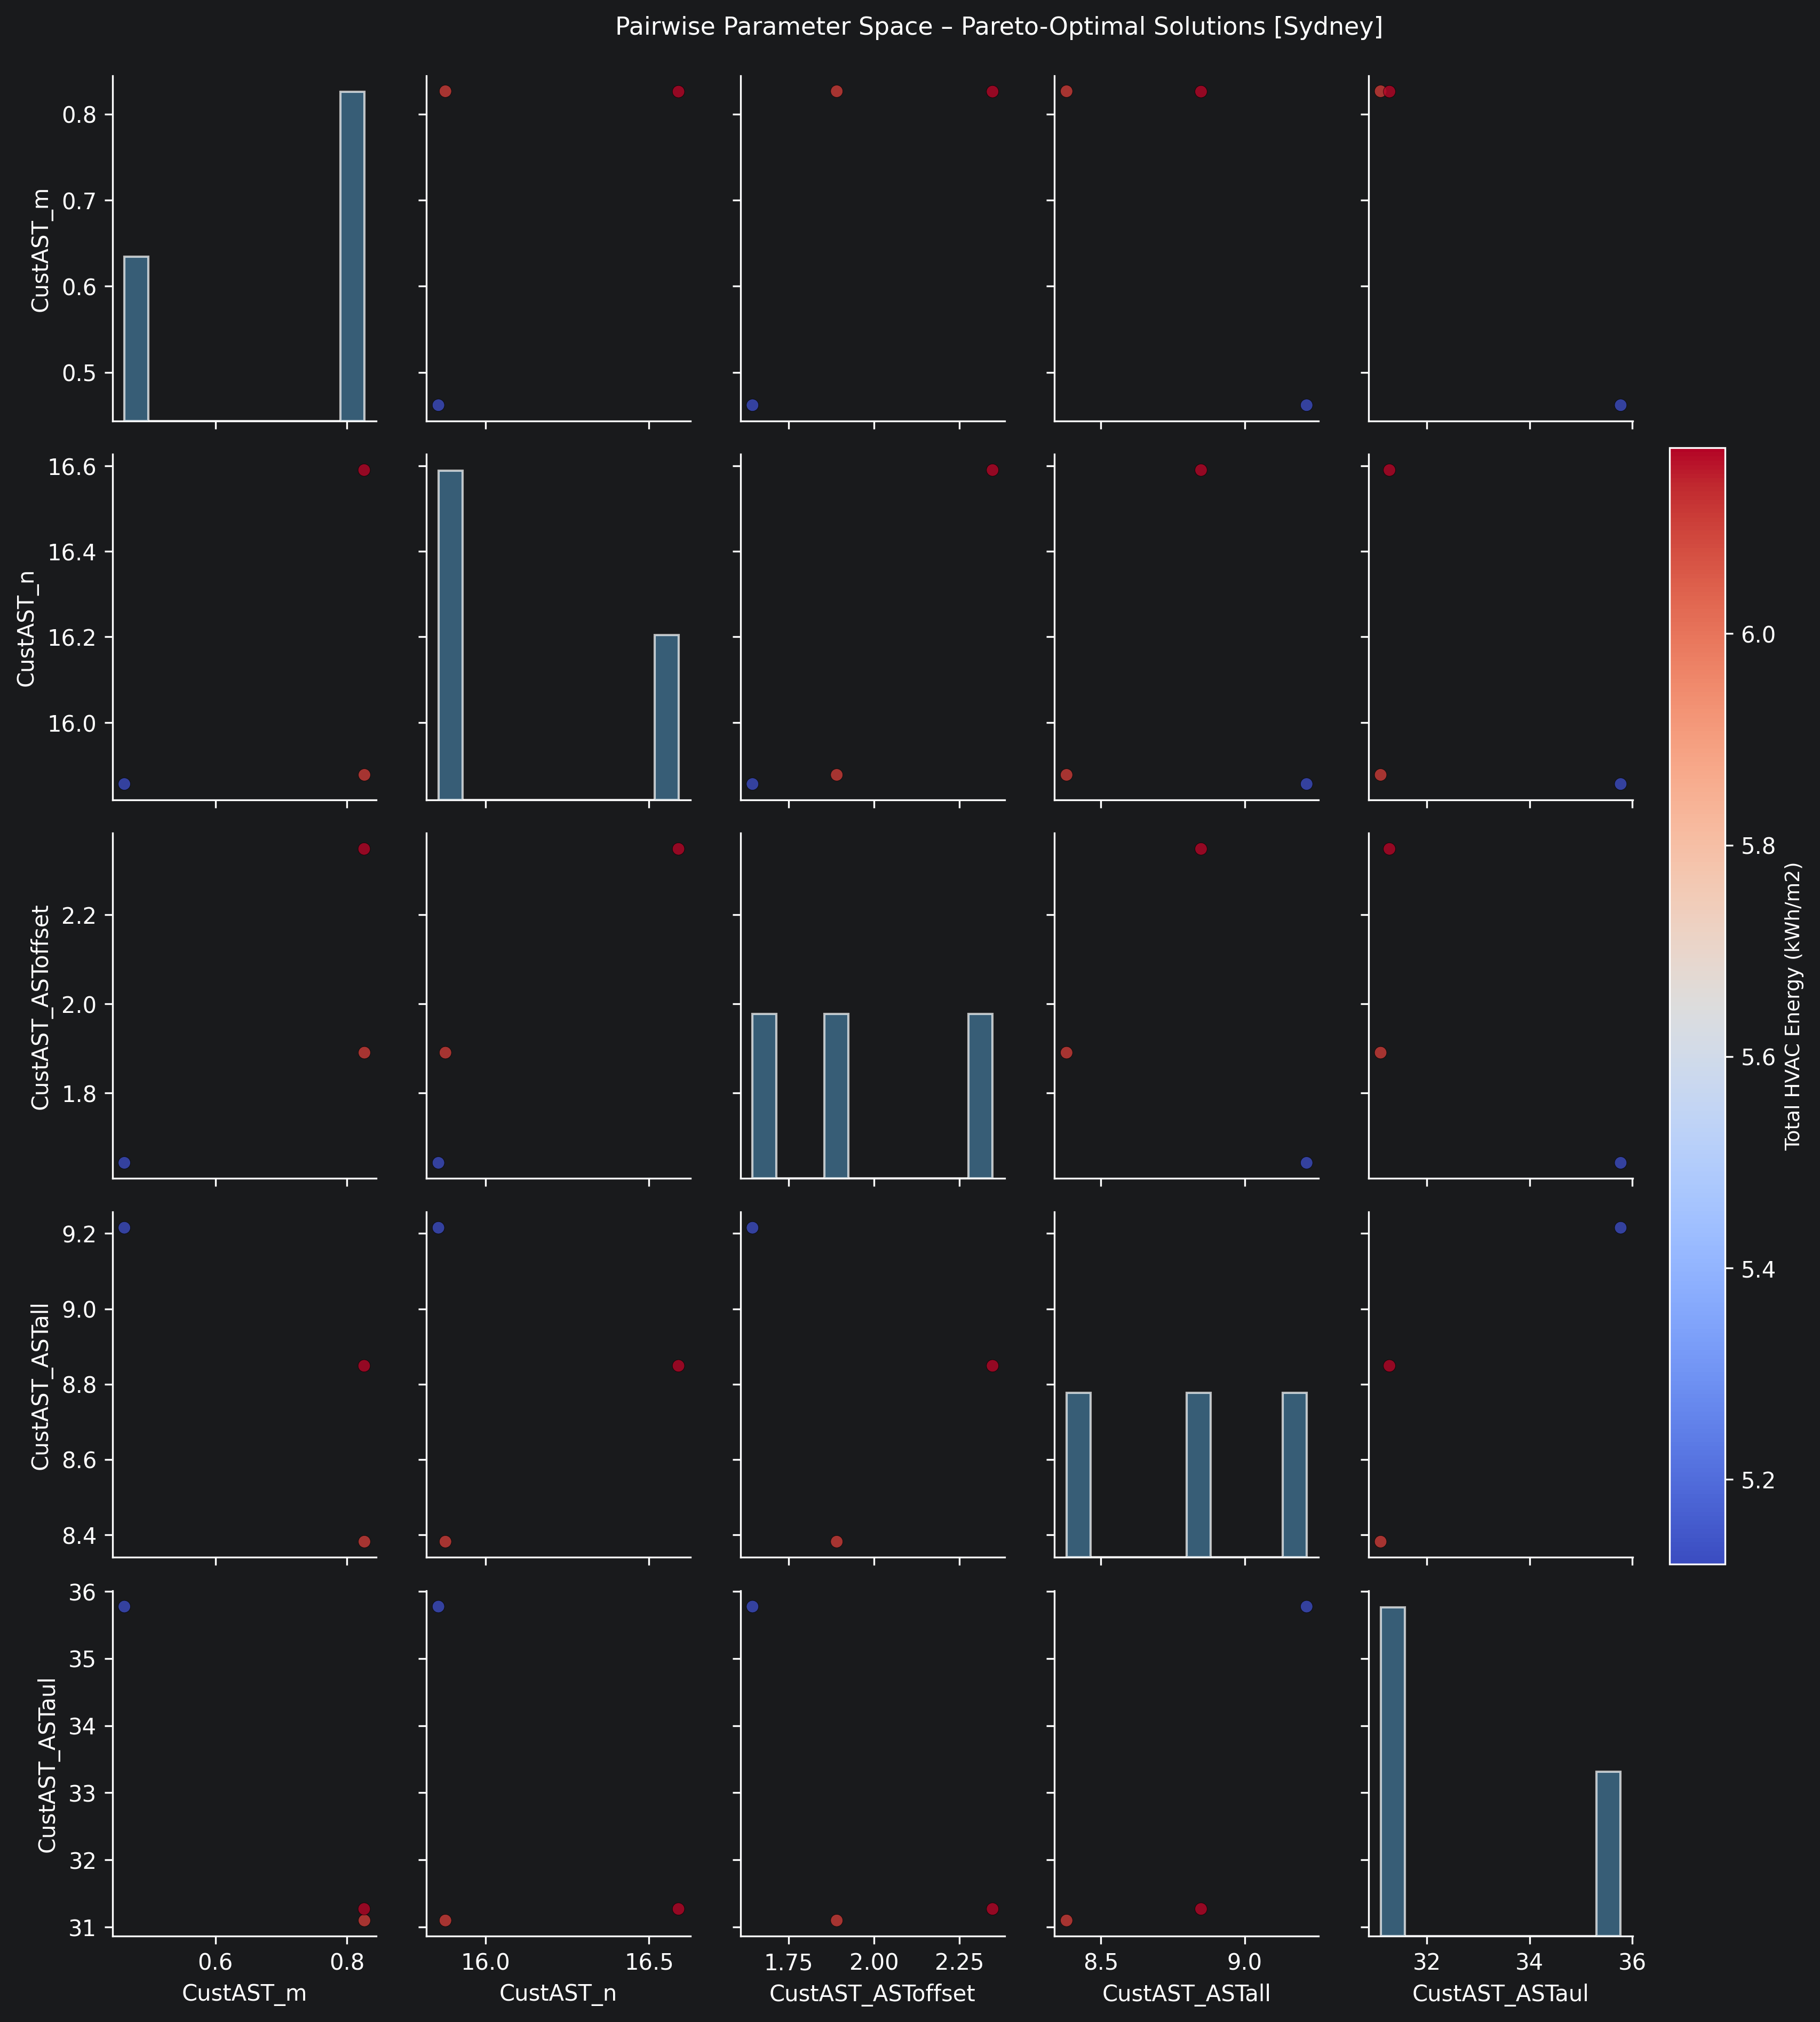

 - plot_pairwise_scatter_matrix_Seville.png


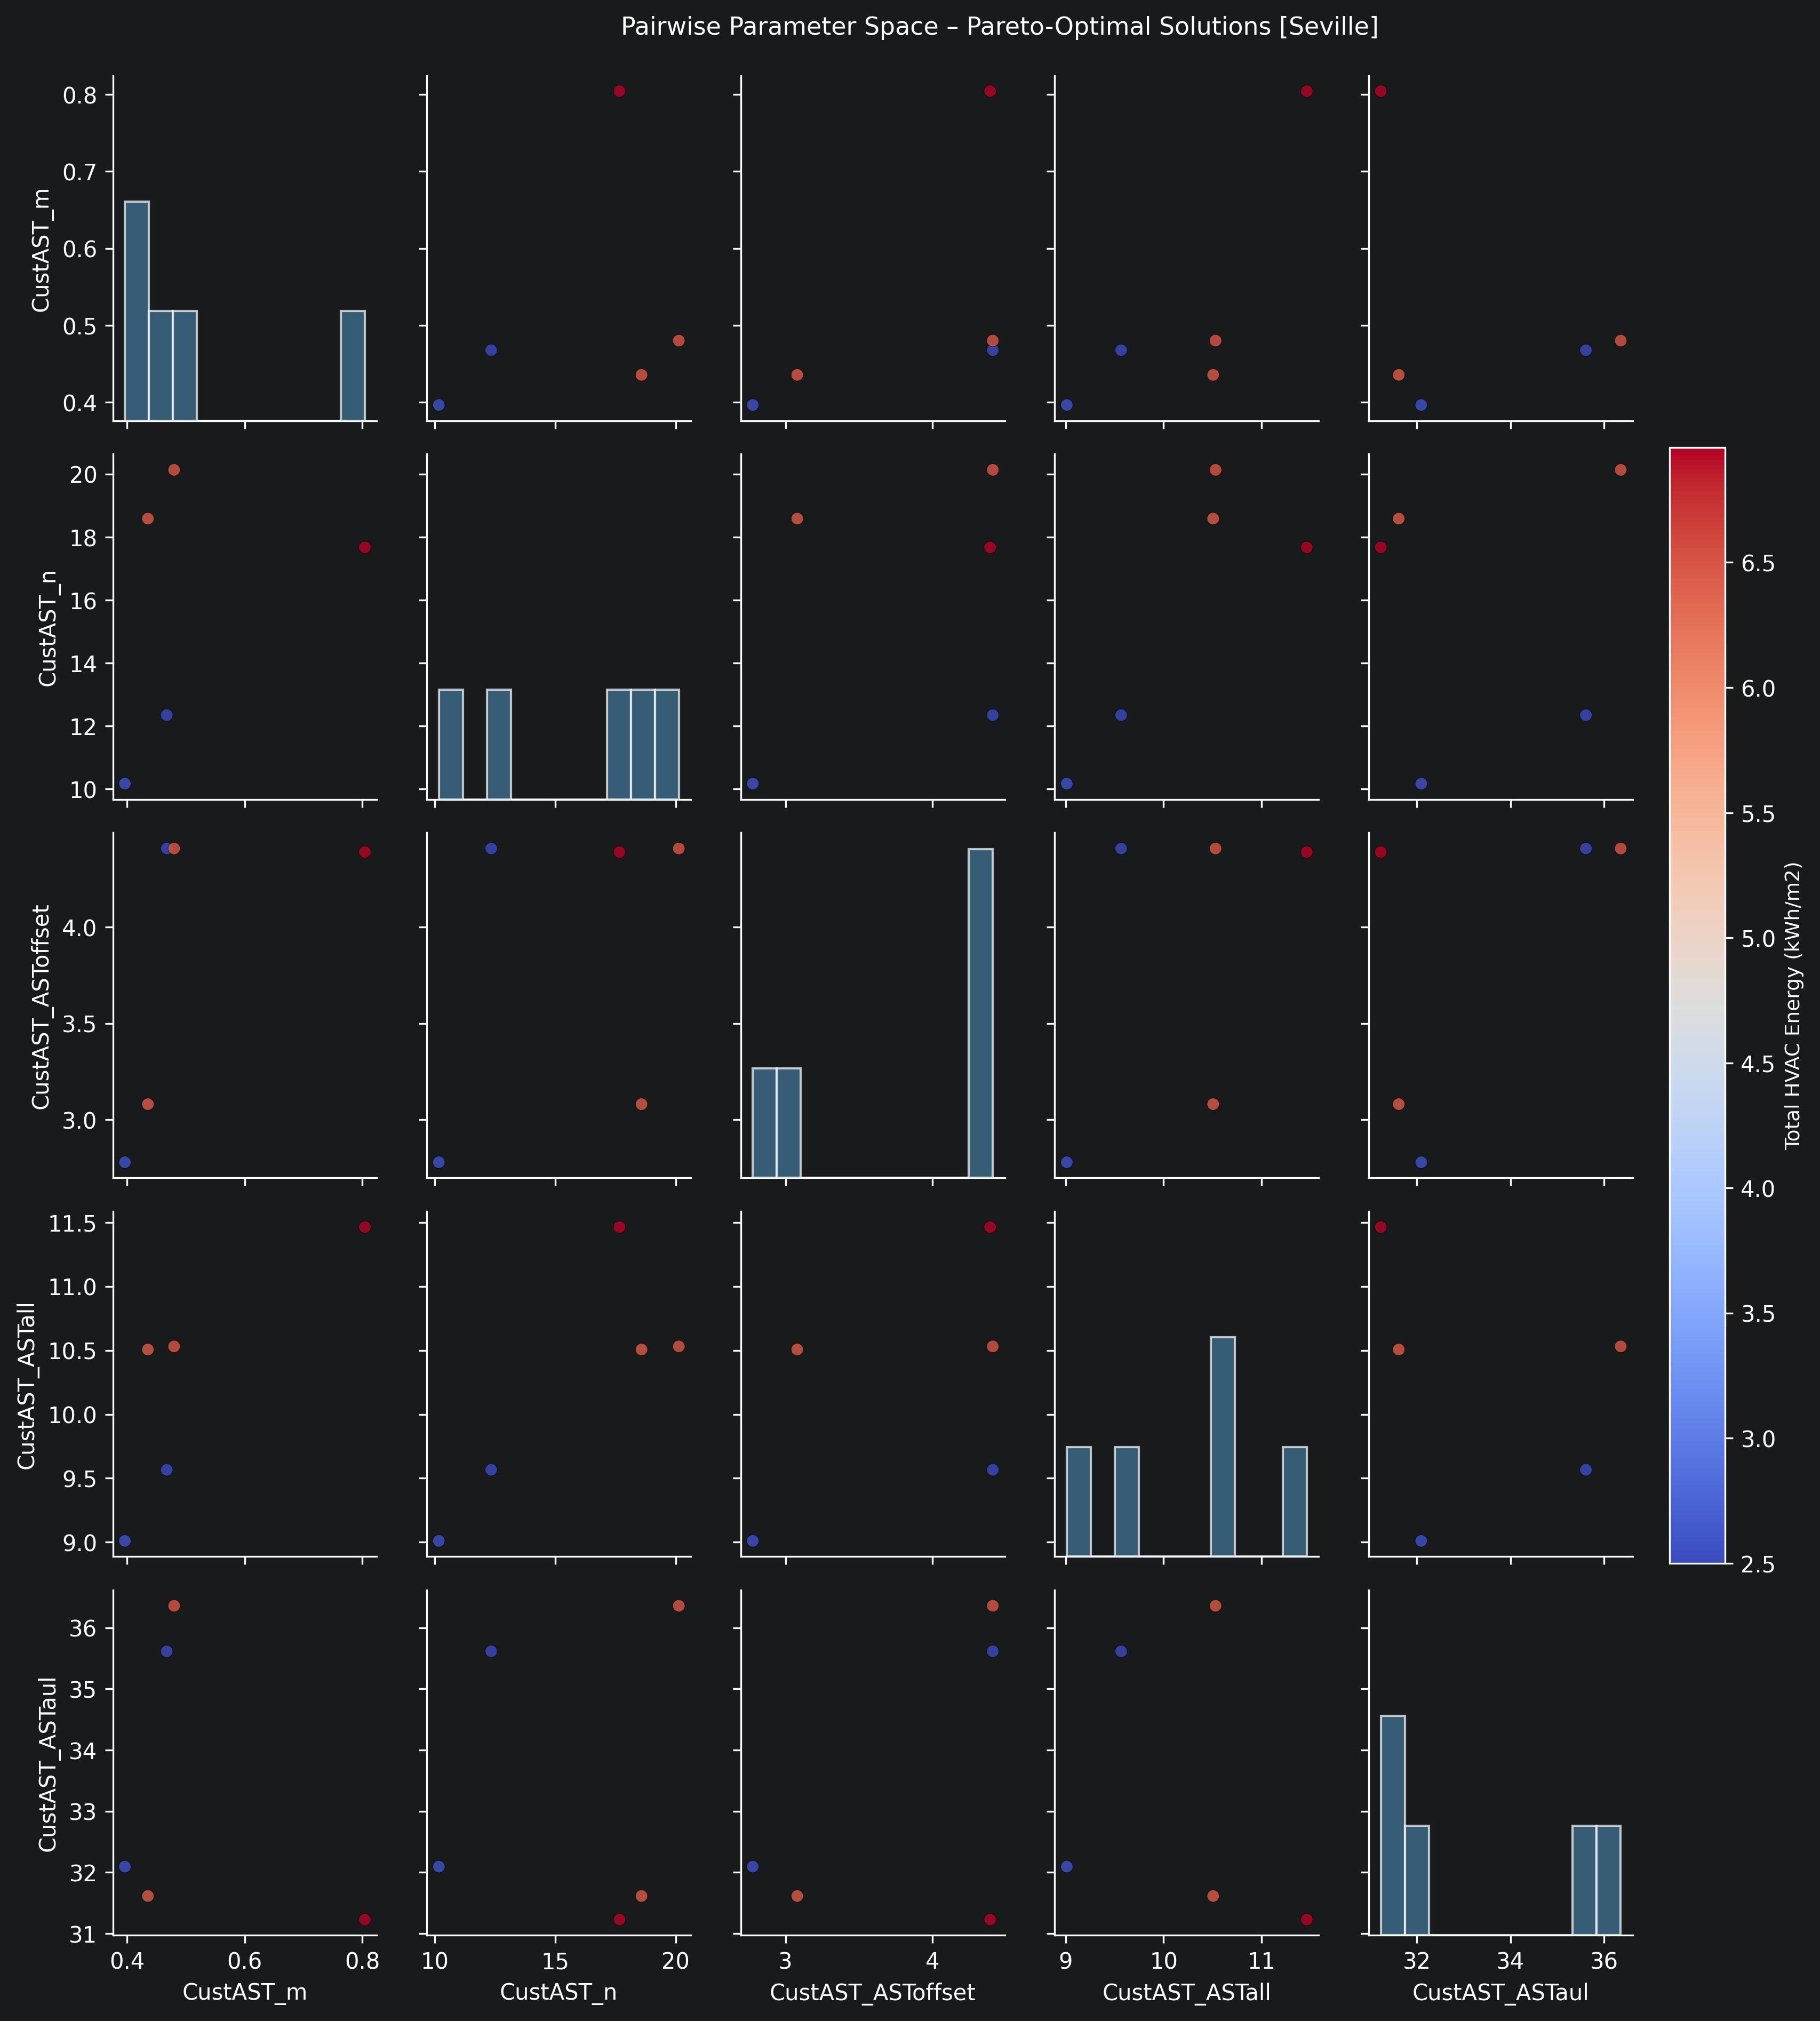

 - plot_parallel_coordinates_Sydney.png


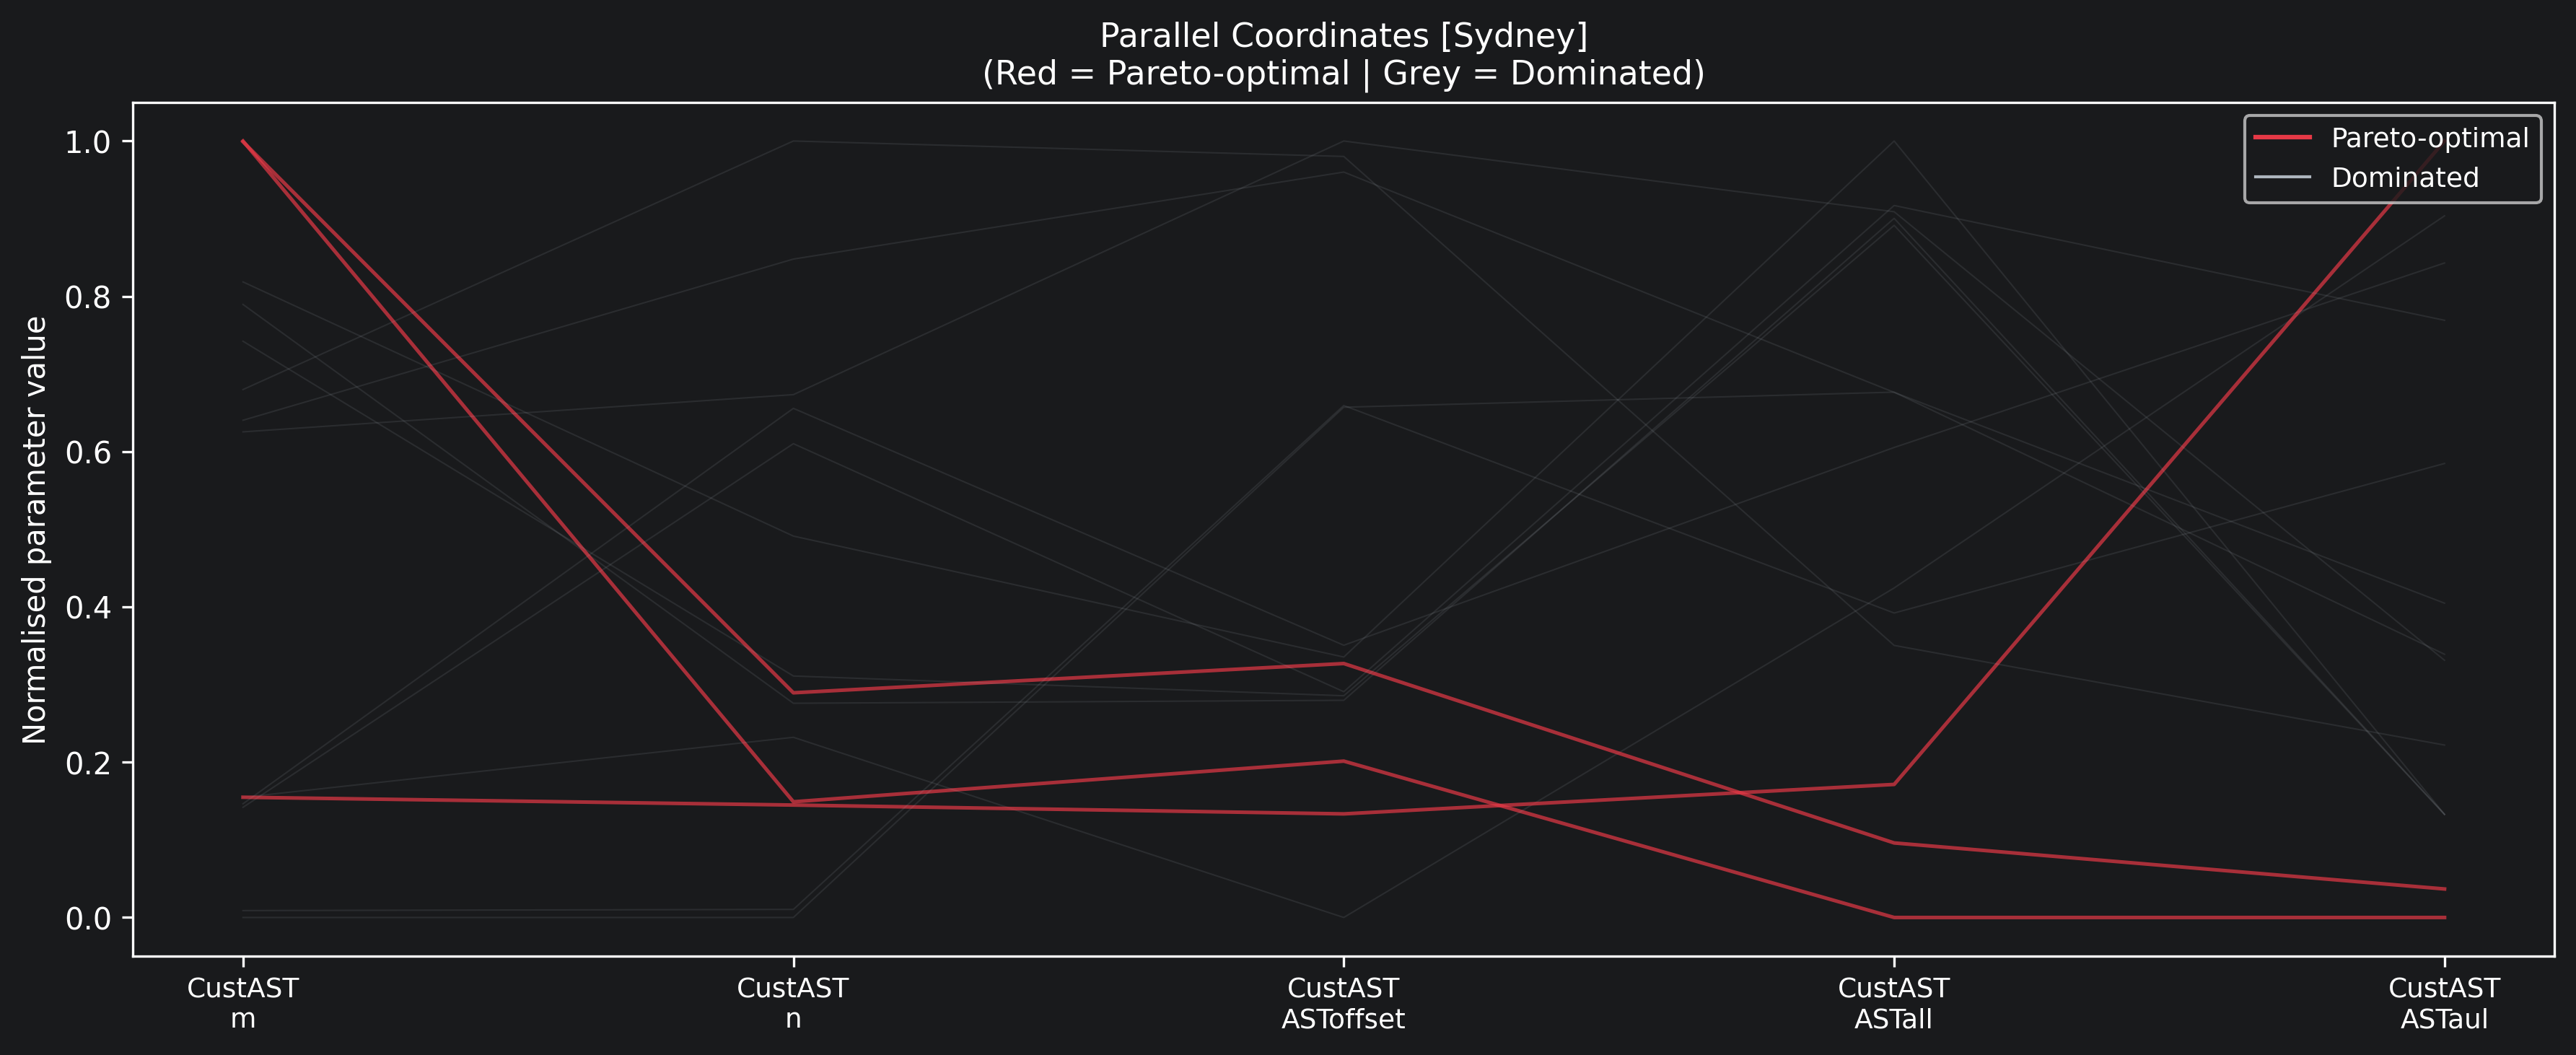

 - plot_parallel_coordinates_Seville.png


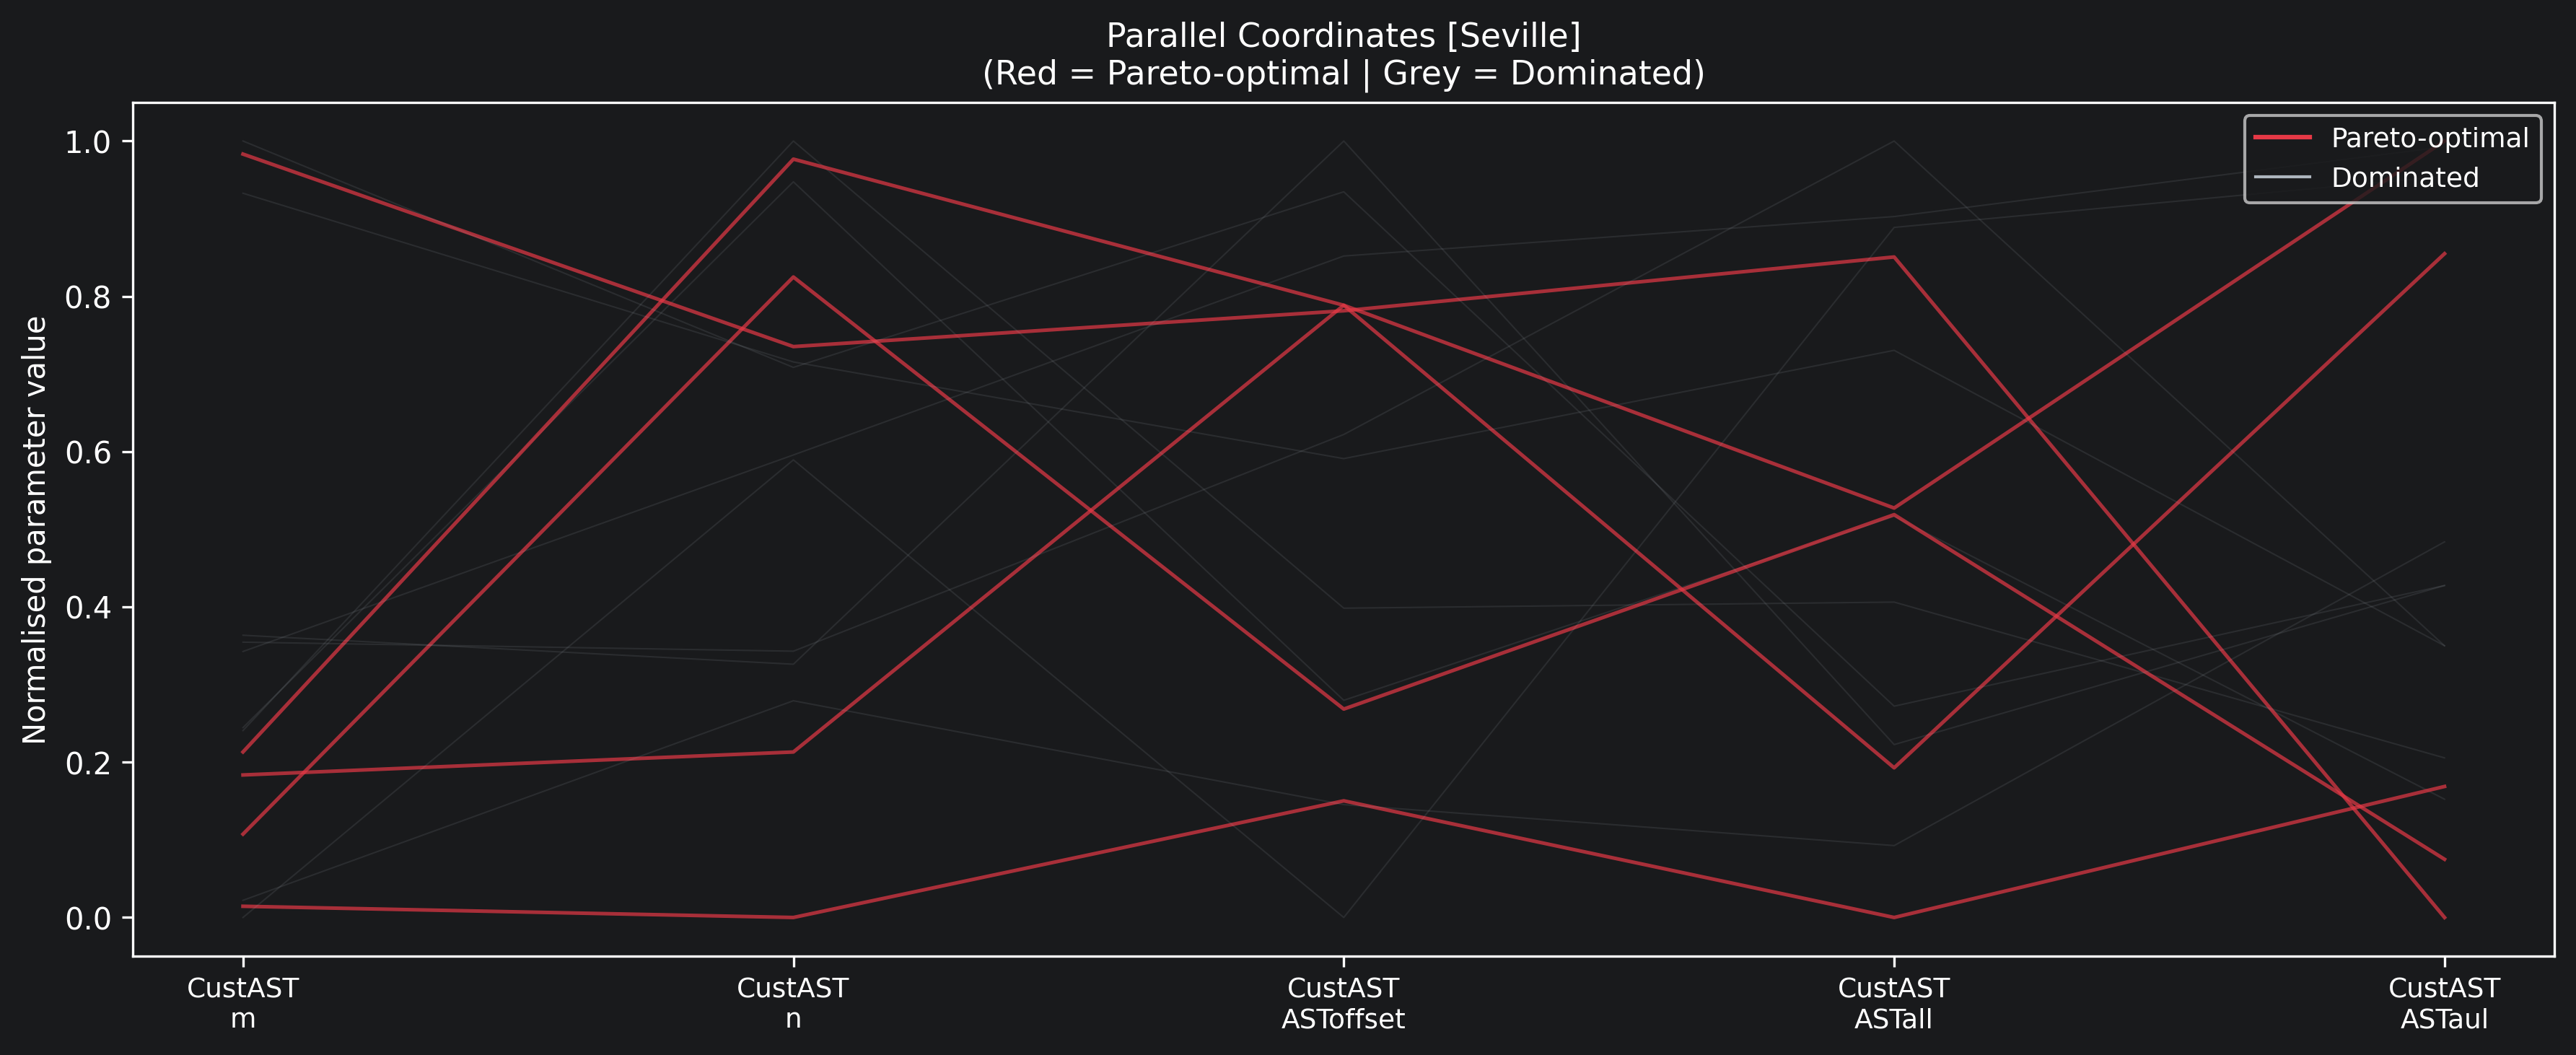

 - plot_pareto_front_Sydney_c_CustAST_ASToffset_s_CustAST_m.png


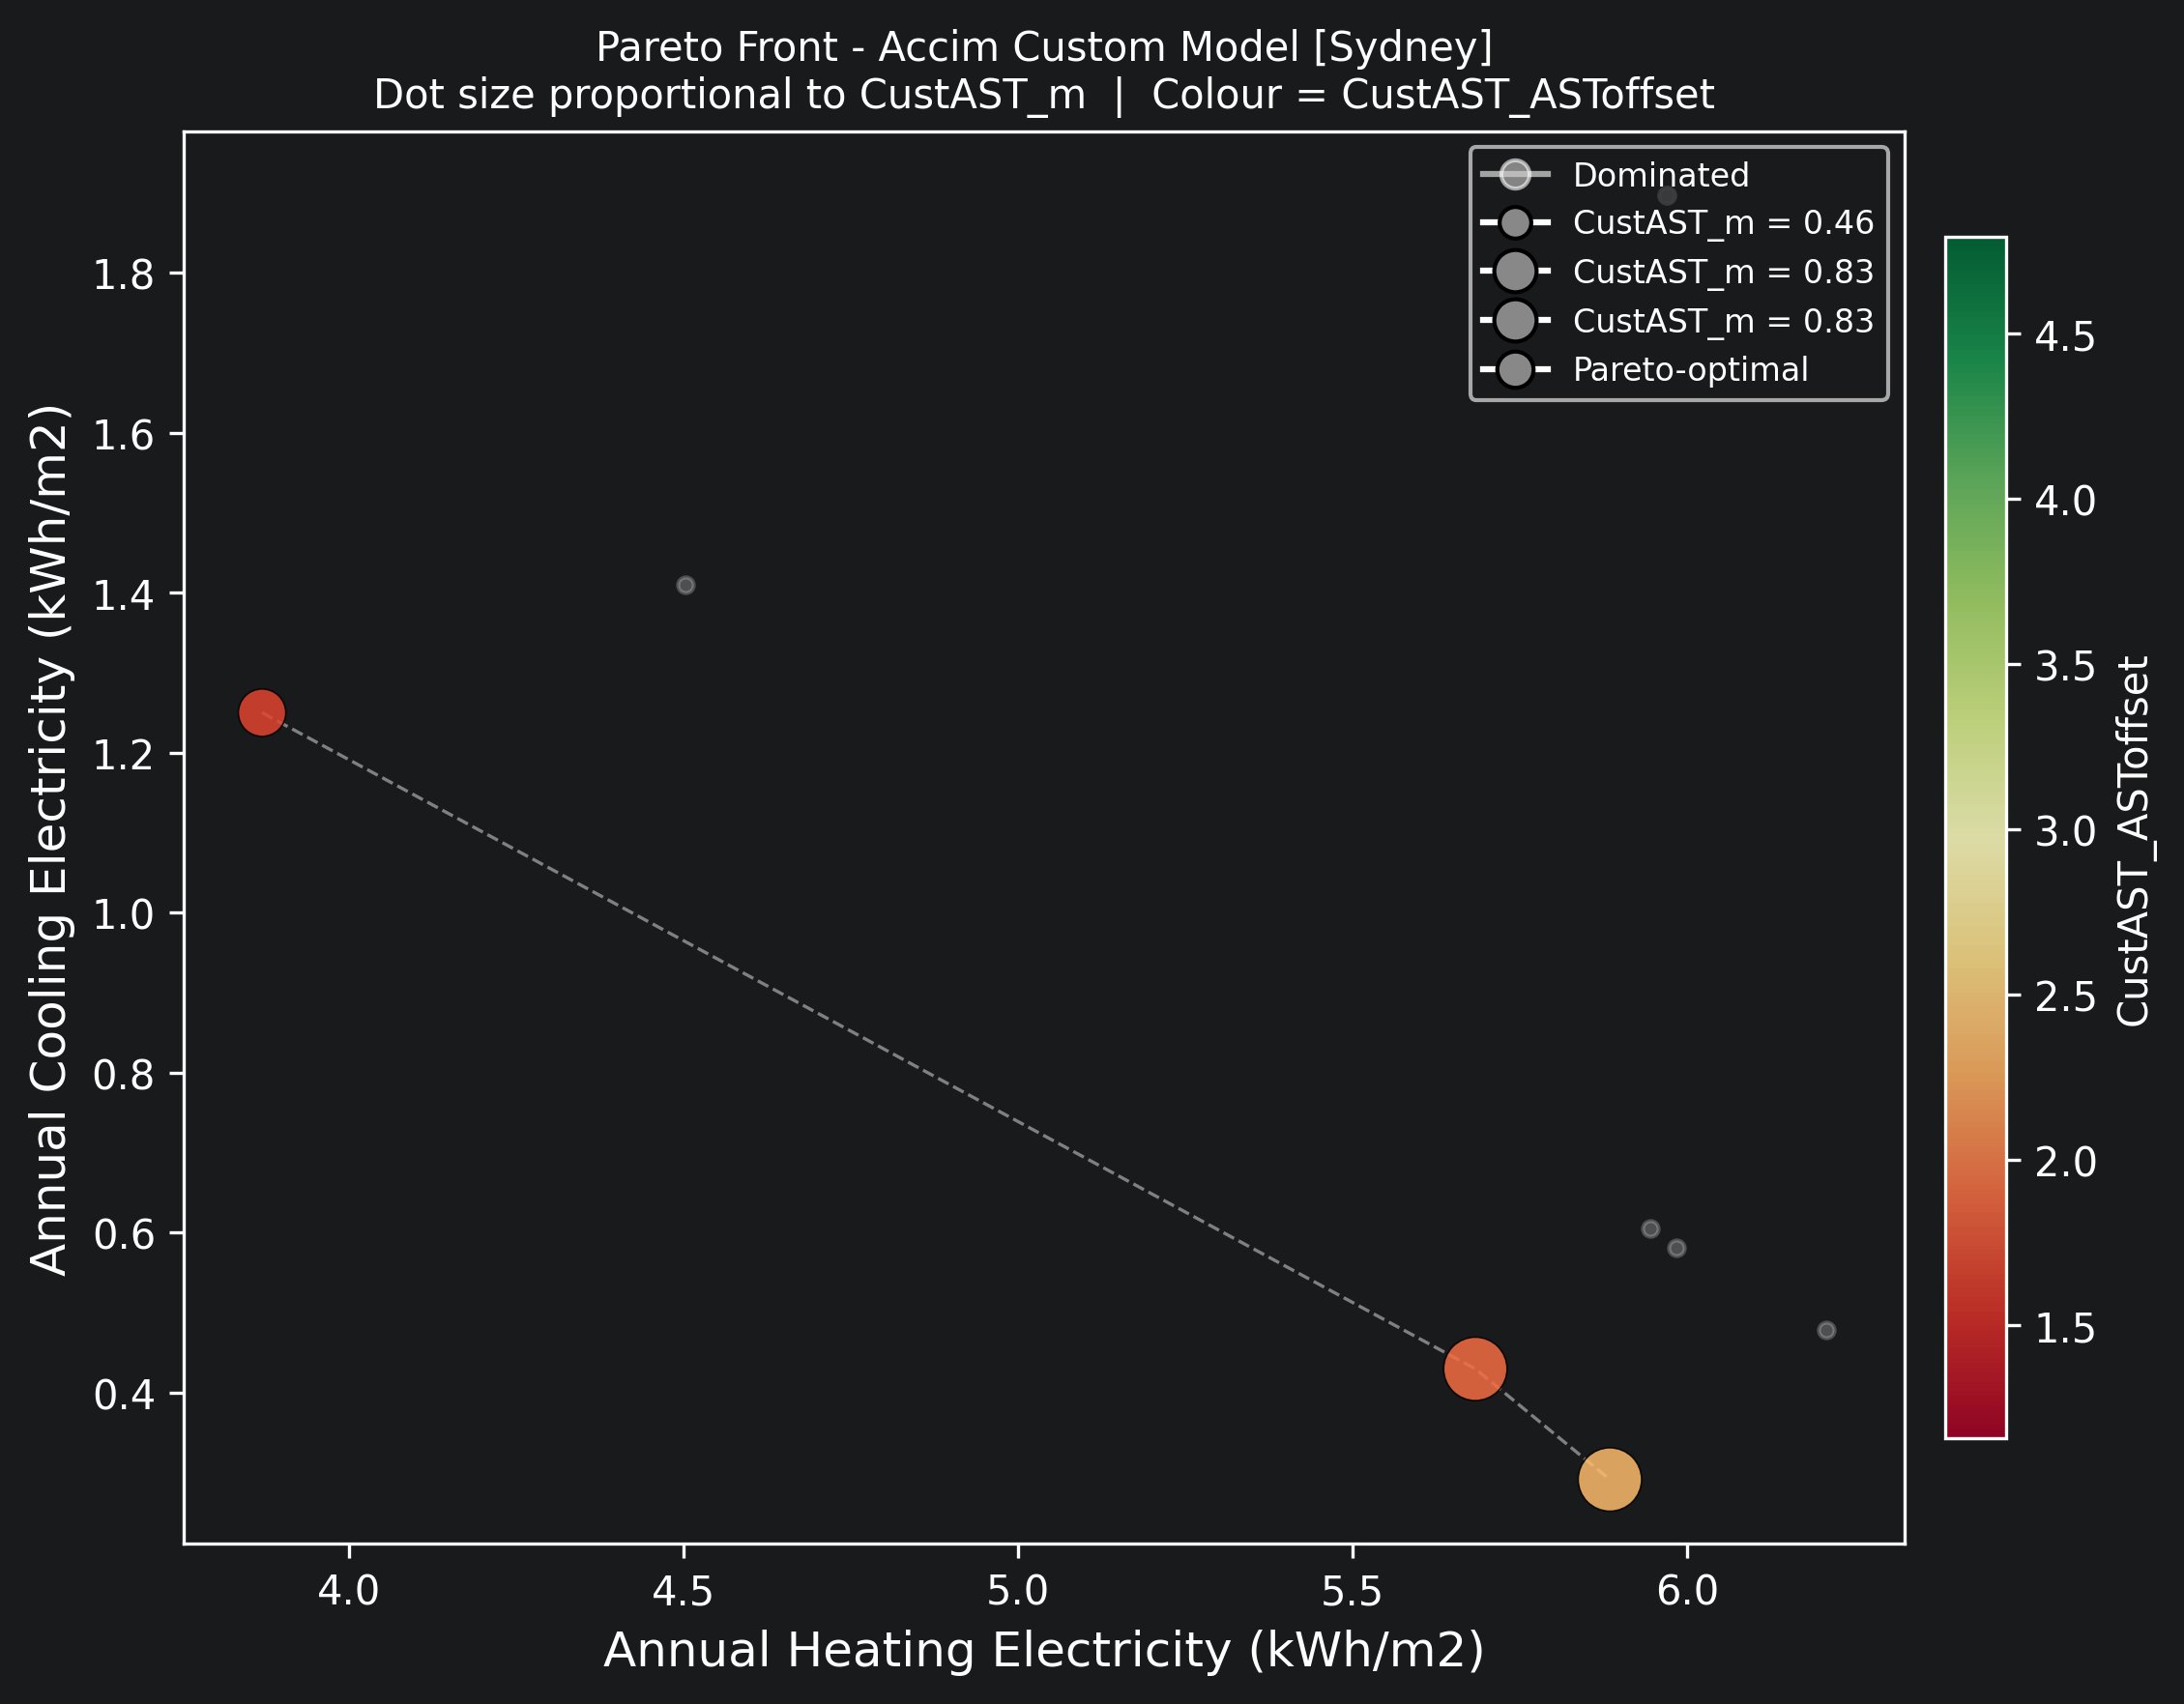

 - plot_pareto_front_Seville_c_CustAST_ASToffset_s_CustAST_m.png


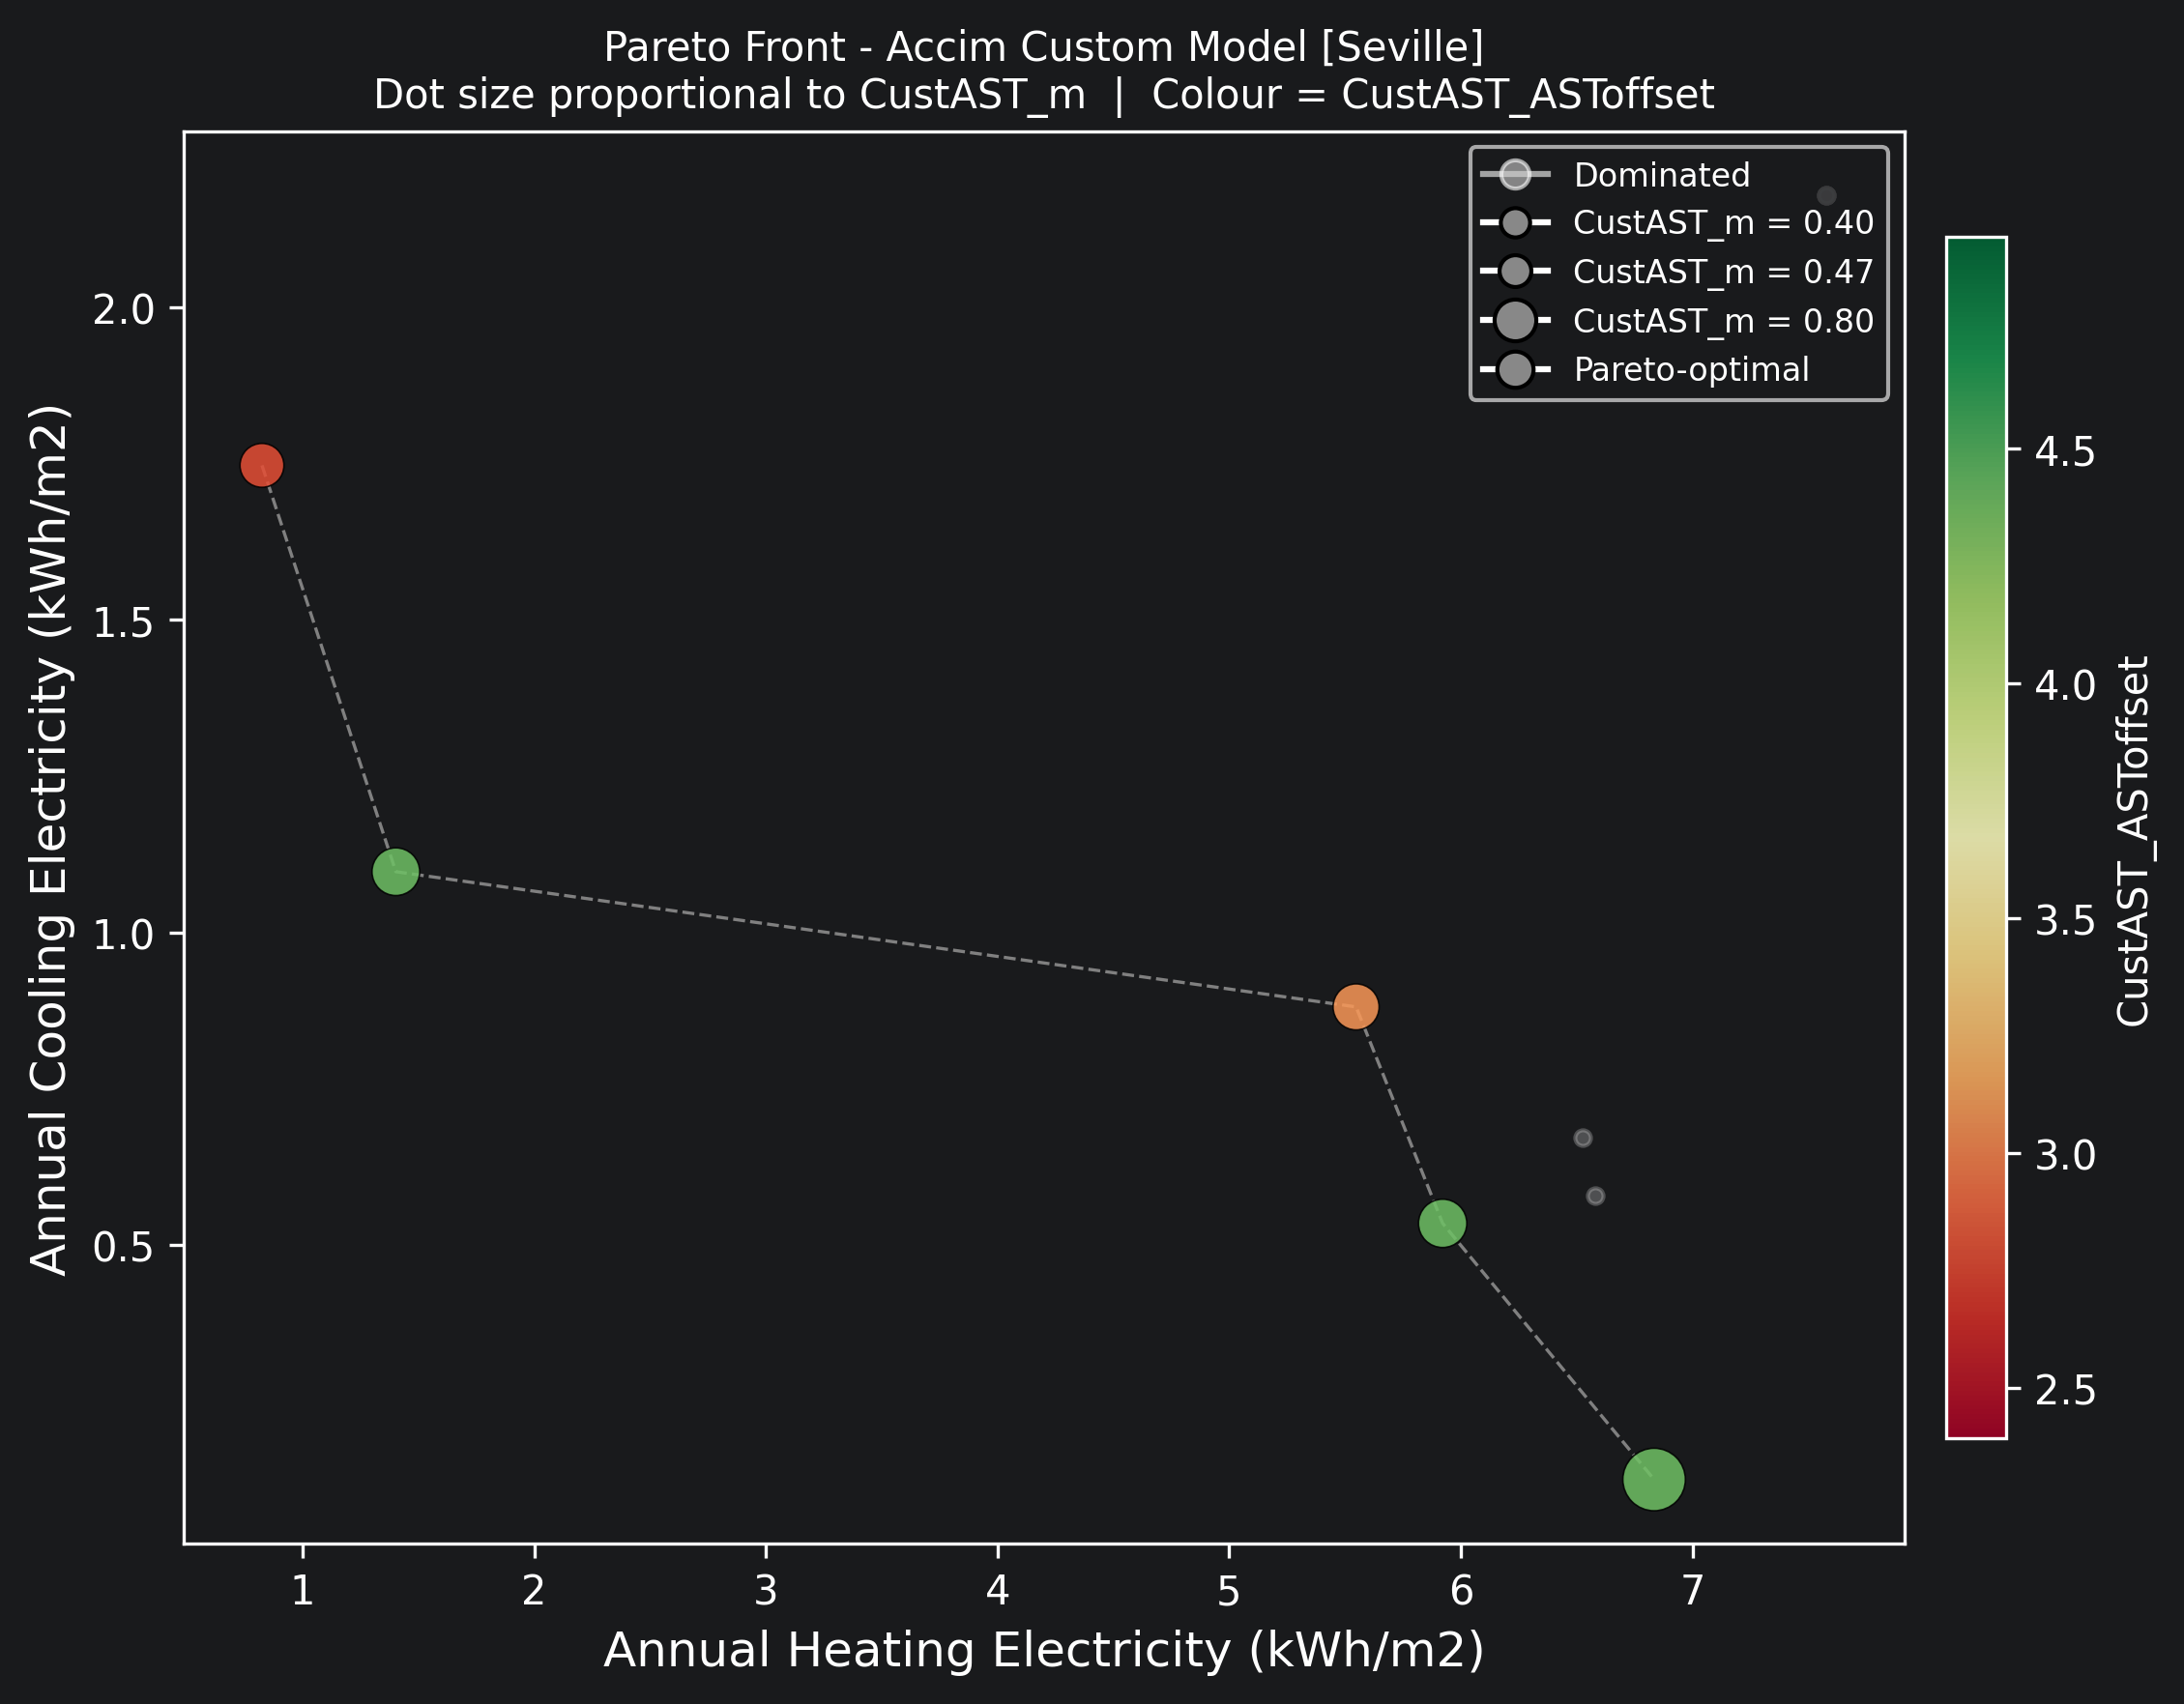

 - plot_parametric_radar_optimisation_group_epw.png


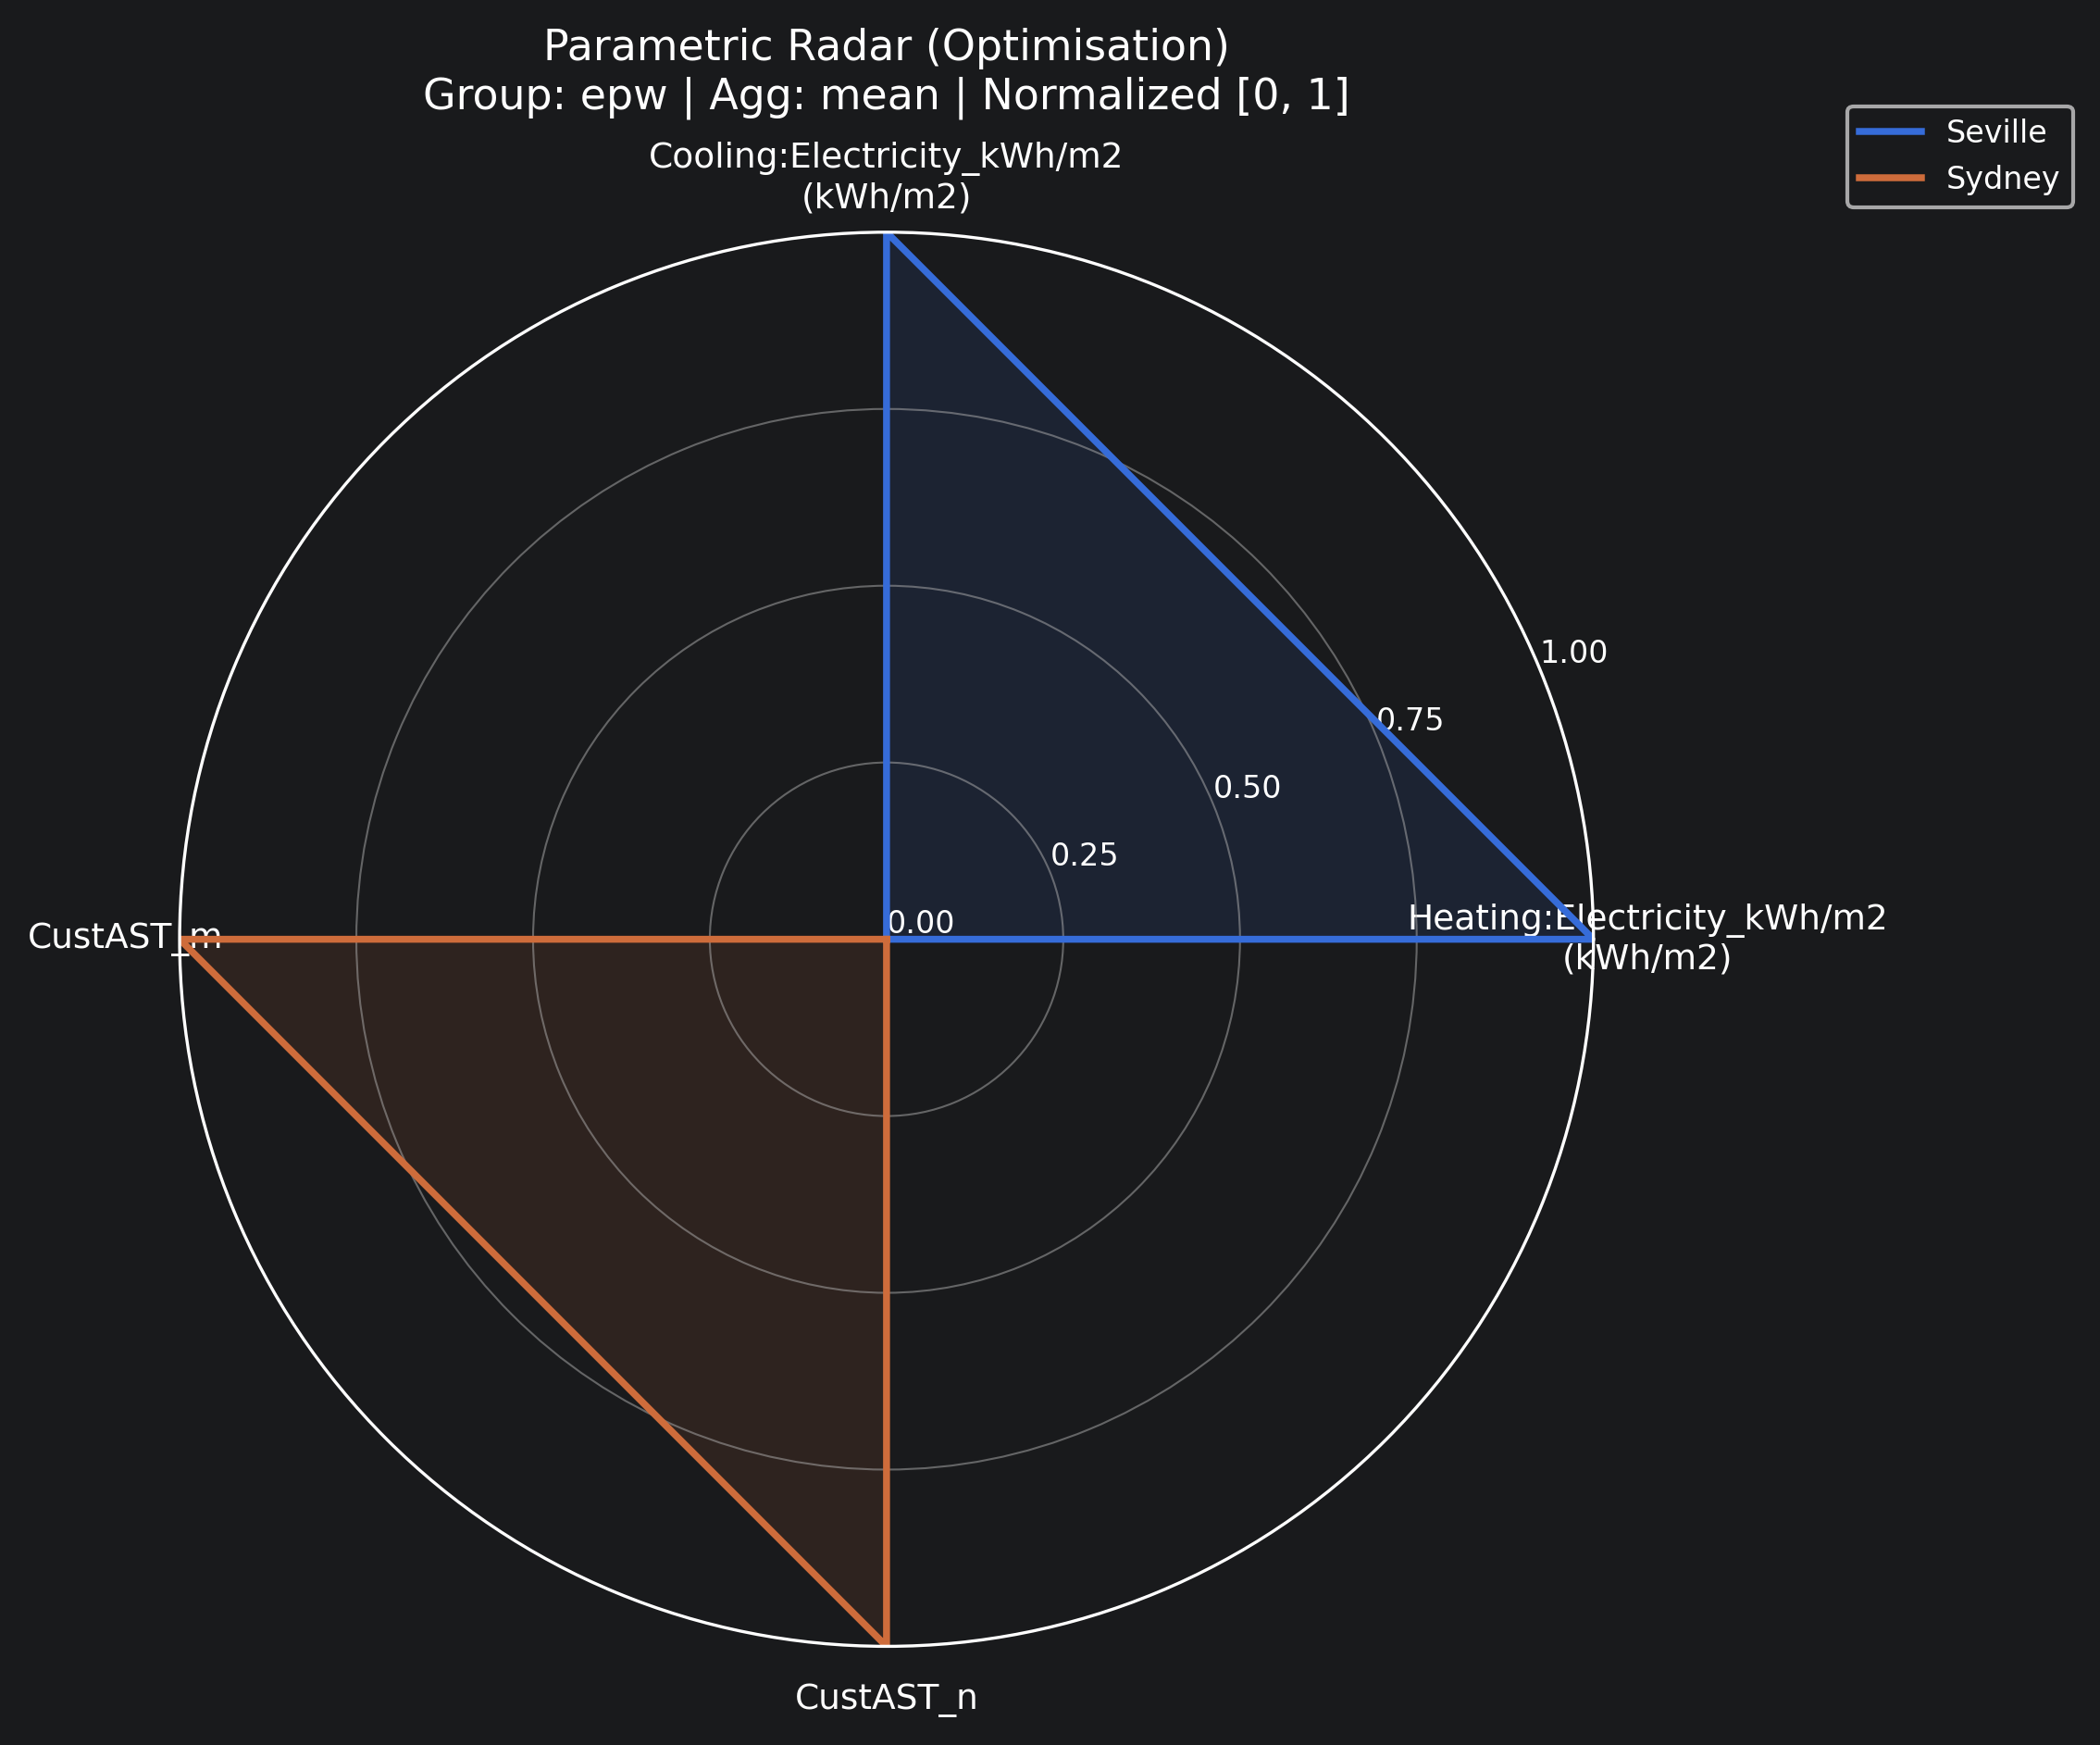

 - plot_parametric_ecdf_optimisation_Heating_Electricity_kWh_m2.png


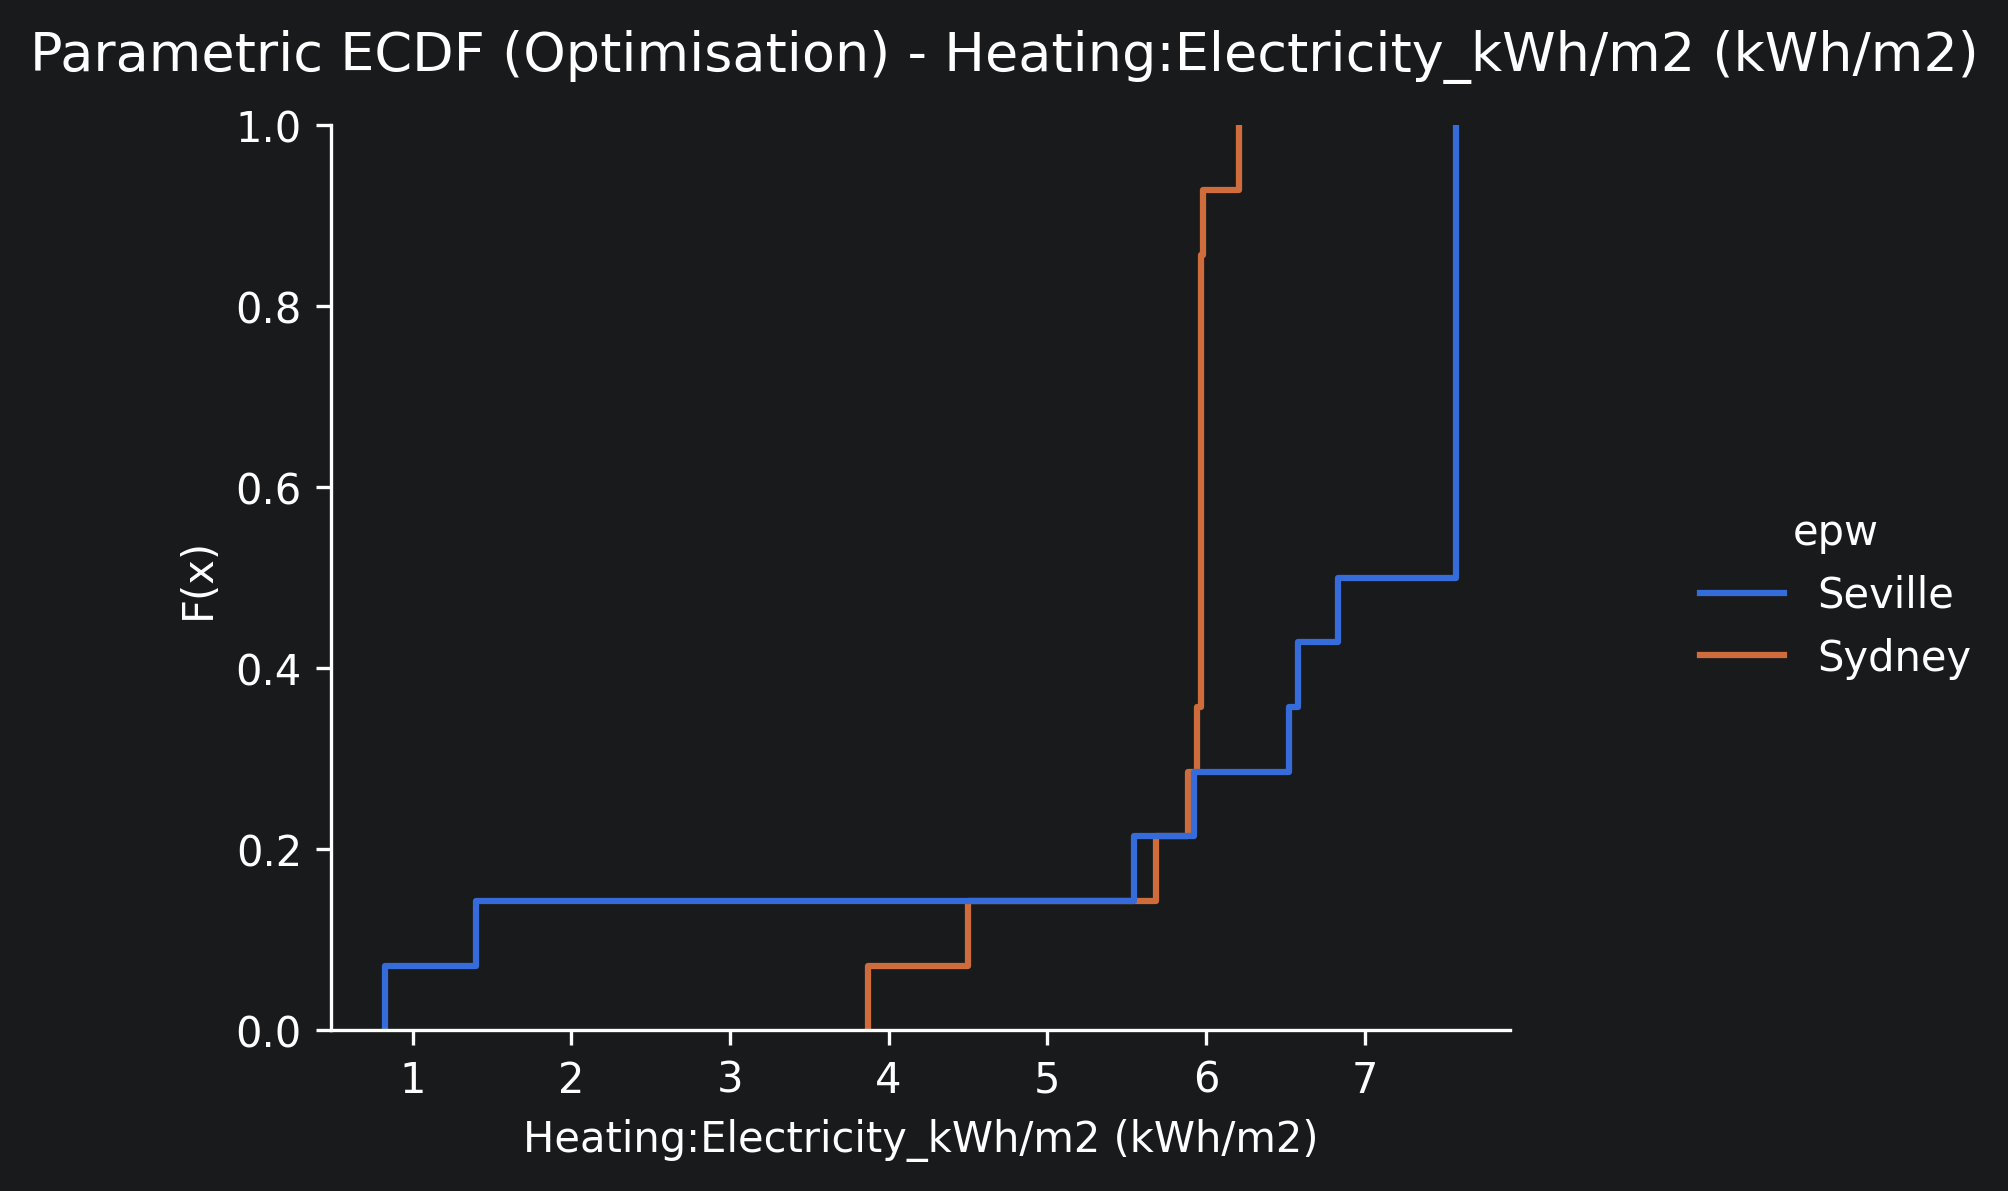

 - plot_parametric_violin_optimisation_Cooling_Electricity_kWh_m2_by_epw.png


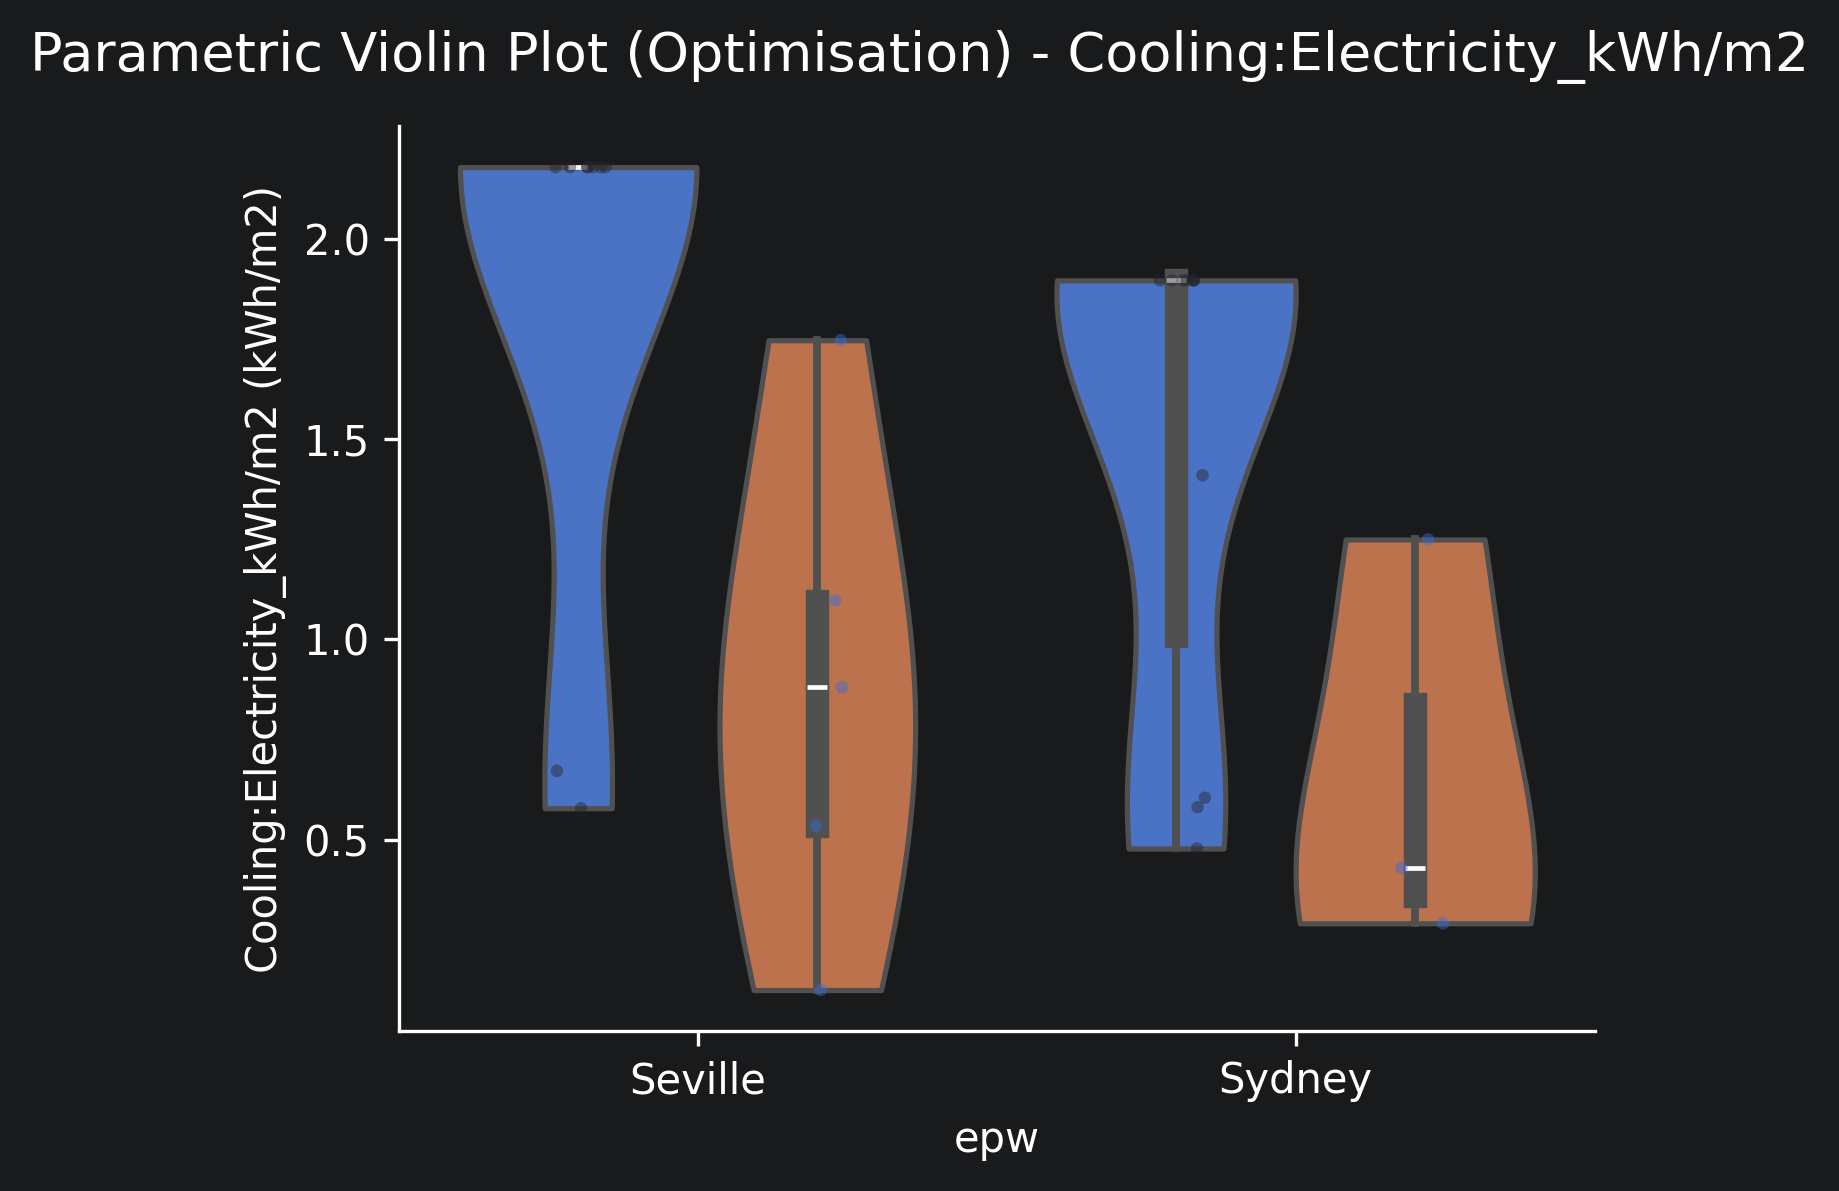

 - plot_parametric_violin_optimisation_Heating_Electricity_kWh_m2_by_epw.png


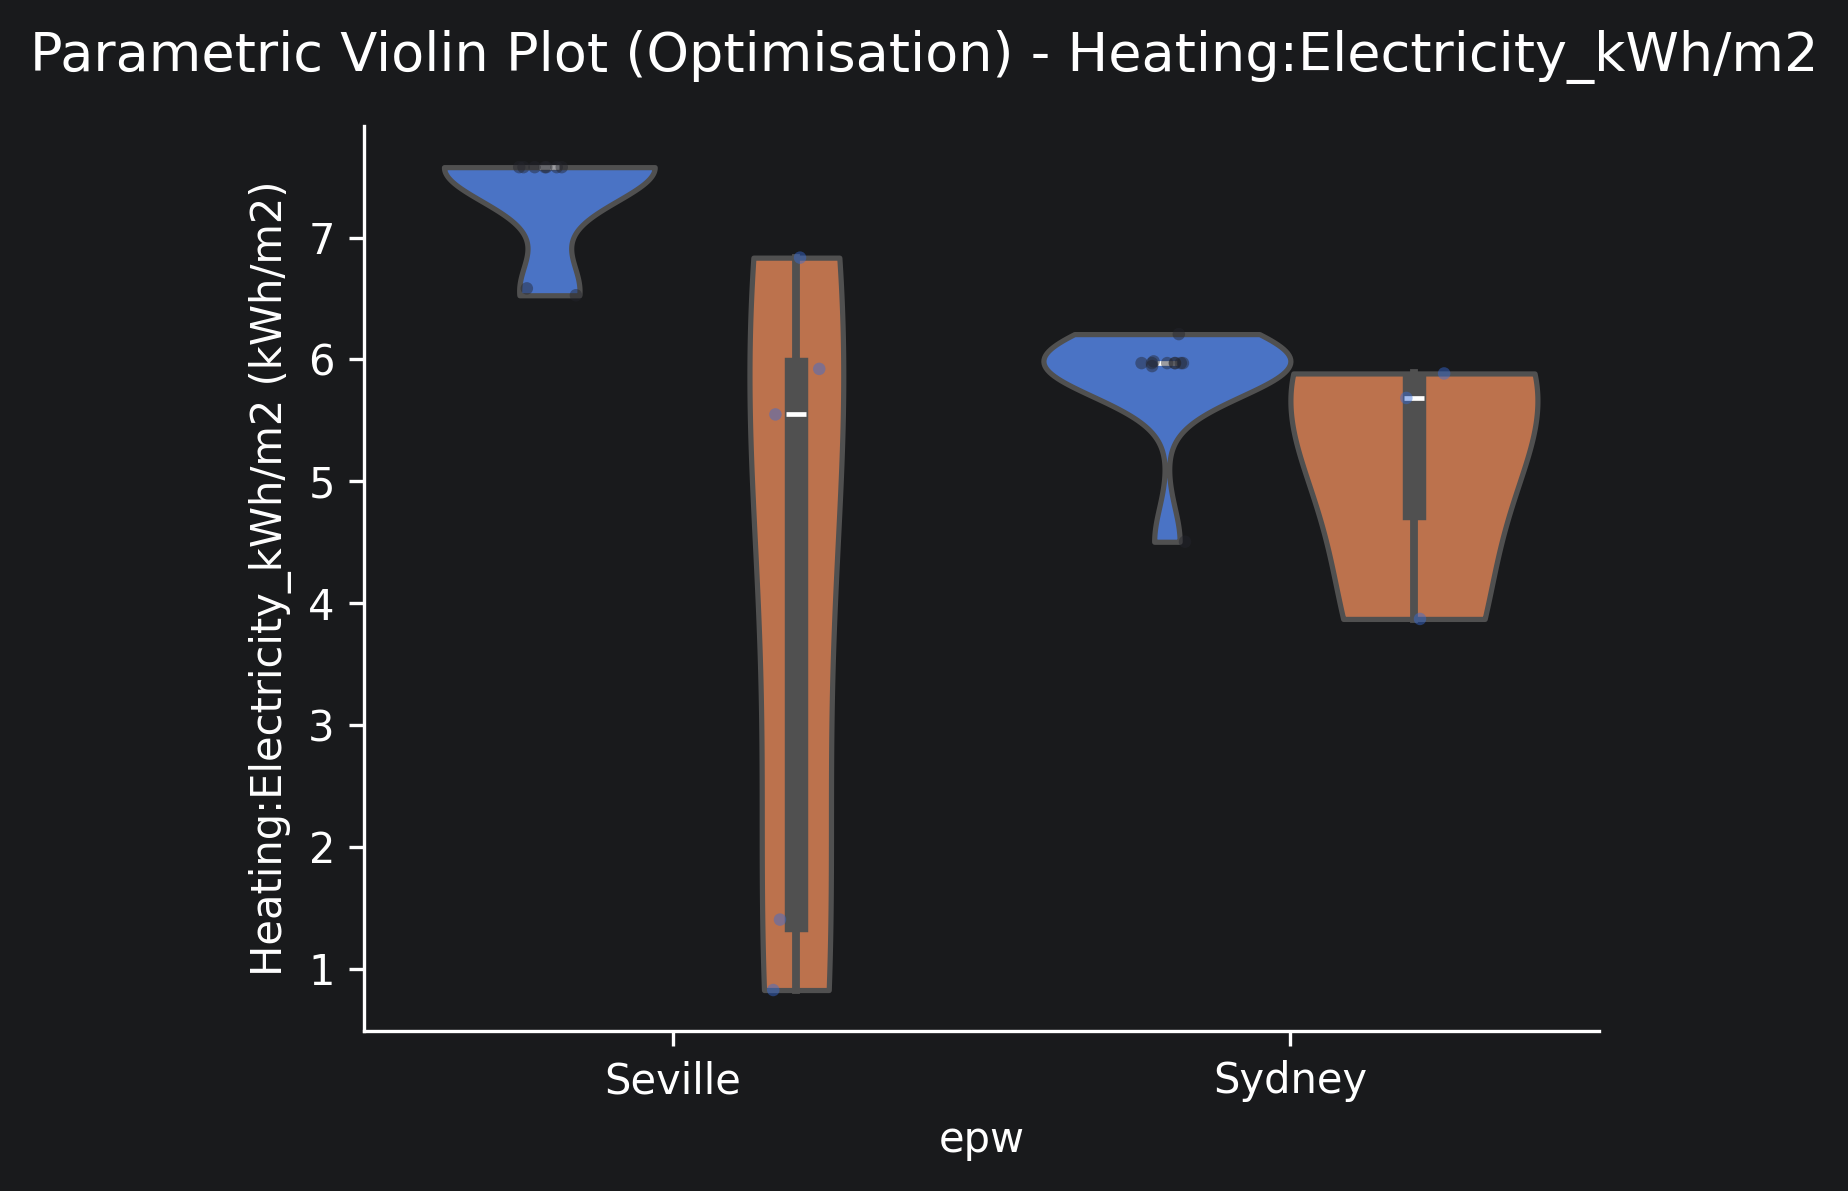

 - plot_parametric_contour_optimisation_Heating_Electricity_kWh_m2_by_CustAST_m_CustAST_n.png


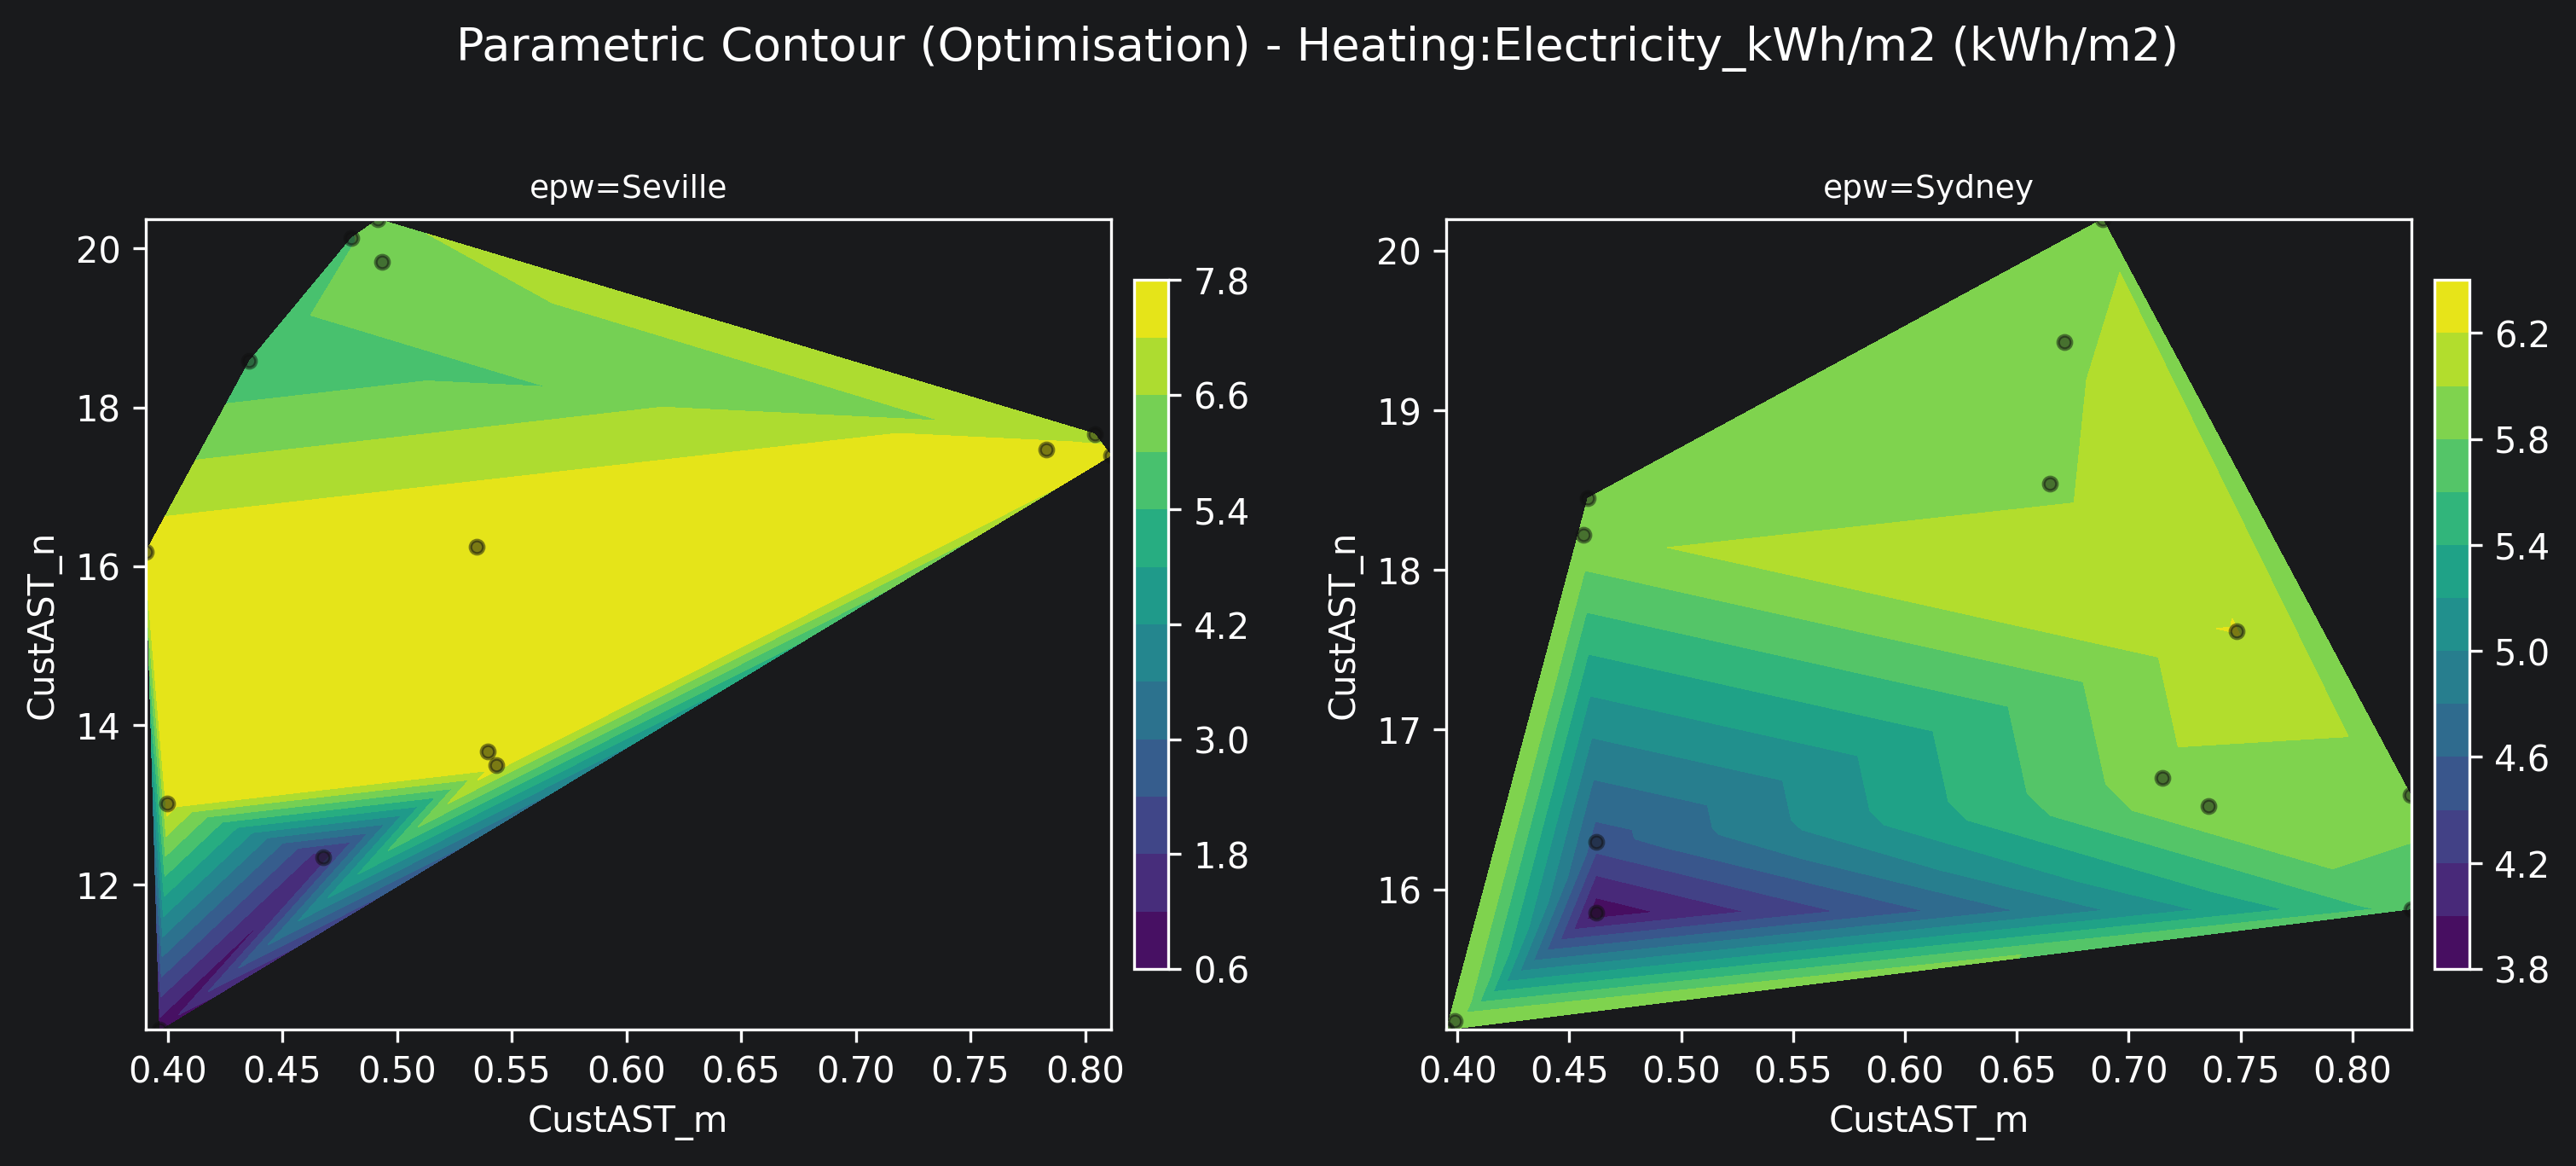

In [4]:
if not outputs_optim.empty:
    optim_case = optim
    plot_out_dir = f"{RESULTS_DIRNAME}/plots"

    optim_case.set_building_floor_area(mode="all")
    if not getattr(optim_case, "outputs_normalized", False):
        optim_case.normalize_outputs(df_types=["optimisation"])

    optim_df = getattr(optim_case, "outputs_optimisation", pd.DataFrame())
    if optim_df.empty:
        print("No optimisation outputs available for plotting")
    else:
        energy_cols = [c for c in optim_df.columns if "Heating:Electricity" in c or "Cooling:Electricity" in c]
        main_energy_col = next((c for c in energy_cols if "Heating:Electricity" in c), energy_cols[0] if energy_cols else None)
        secondary_energy_col = next((c for c in energy_cols if c != main_energy_col), main_energy_col)
        if main_energy_col is None:
            raise ValueError("No se encontraron columnas energeticas para visualizar.")

        optim_case.plot_categorical_boxplots(
            df_source="optimisation",
            y_vars=[main_energy_col, secondary_energy_col],
            col="epw",
            row=None,
            hue="CustAST_m",
            out_dir=plot_out_dir,
            normalize_per_m2=False,
            show_points=True,
            sharey=True,
            height=3.6,
            aspect=1.1,
        )

        optim_case.plot_parametric_scatter(
            x="CustAST_m",
            y=main_energy_col,
            df_source="optimisation",
            hue="epw",
            style="pareto-optimal",
            out_dir=plot_out_dir,
            normalize_per_m2=False,
        )

        optim_case.plot_parametric_lines(
            x="CustAST_n",
            y_vars=[main_energy_col, secondary_energy_col],
            df_source="optimisation",
            hue="epw",
            col="idf",
            out_dir=plot_out_dir,
            normalize_per_m2=False,
        )

        optim_case.plot_parametric_heatmap(
            x="CustAST_m",
            y="CustAST_n",
            z=main_energy_col,
            df_source="optimisation",
            col="epw",
            out_dir=plot_out_dir,
            normalize_per_m2=False,
        )

        optim_case.plot_parametric_density_2d(
            x="CustAST_ASToffset",
            y=main_energy_col,
            kind="hexbin",
            df_source="optimisation",
            col="epw",
            out_dir=plot_out_dir,
            normalize_per_m2=False,
        )

        optim_case.plot_parametric_contour(
            x="CustAST_m",
            y="CustAST_n",
            z=main_energy_col,
            df_source="optimisation",
            col="epw",
            out_dir=plot_out_dir,
            normalize_per_m2=False,
        )

        optim_case.plot_parametric_distributions(
            x="epw",
            y_vars=[main_energy_col, secondary_energy_col],
            kind="violin",
            df_source="optimisation",
            hue="pareto-optimal",
            out_dir=plot_out_dir,
            normalize_per_m2=False,
            show_points=True,
        )

        optim_case.plot_parametric_ecdf(
            x=main_energy_col,
            df_source="optimisation",
            hue="epw",
            out_dir=plot_out_dir,
            normalize_per_m2=False,
        )

        optim_case.plot_parametric_radar(
            metrics=[main_energy_col, secondary_energy_col, "CustAST_m", "CustAST_n"],
            group_by="epw",
            df_source="optimisation",
            out_dir=plot_out_dir,
            normalize_per_m2=False,
        )

        optim_case.plot_pareto_front(
            color_by="CustAST_ASToffset",
            size_by="CustAST_m",
            out_dir=plot_out_dir,
            normalize_per_m2=False,
        )
        optim_case.plot_parallel_coordinates(out_dir=plot_out_dir)
        optim_case.plot_pairwise_scatter_matrix(
            out_dir=plot_out_dir,
            normalize_per_m2=False,
        )
        optim_case.plot_best_compromise_solutions(
            out_dir=plot_out_dir,
            normalize_per_m2=False,
            separate_by_epw=PARETO_SEPARATE_BY_EPW,
            separate_by_idf=PARETO_SEPARATE_BY_IDF,
        )

        print("PlottingMixin plots saved in:", plot_out_dir)

        from IPython.display import Image, display

        latest_plots = sorted(
            Path(plot_out_dir).glob("plot_*.png"),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )[:12]
        print("Latest plot files:")
        for plot_path in latest_plots:
            print(" -", plot_path.name)
            display(Image(filename=str(plot_path)))
else:
    print("No optimization outputs to visualize yet.")
